<h1> Prediction of Final Steel Temperature at a Steel Production Plant</h1> 

<h2> Part 1. Data Preprocessing</h2> 

<h3>1.1. Imports</h3> 

<h4>1.1.1. Libraries</h4> 

In [1]:
import os
from dotenv import load_dotenv
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import sklearn
from sklearn.ensemble import IsolationForest 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

import pyod
from pyod.models.knn import KNN 

import catboost
from catboost import CatBoostRegressor
from catboost import Pool, cv

import optuna

import time
import warnings
warnings.filterwarnings('ignore')

#plt.style.use('dark_background')

print('Libraries loaded')

Libraries loaded


c:\Users\iulii\Documents\Pet Projects\steel_temperature\venv_steel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h4>1.1.2. Environment Variables</h4> 

In [2]:
# Load environment variables
load_dotenv()

True

In [3]:
# Constants
# Data directory
DATA_DIR = os.getenv('DATA_DIR', './data')
# Results directory
RESULTS_DIR = os.getenv('RESULTS_DIR', './results')

<h3>1.2. Load Data</h3> 

In [4]:
arc = pd.read_csv(Path(DATA_DIR, 'data_arc_new.csv'))    
bulk = pd.read_csv(Path(DATA_DIR, 'data_bulk_new.csv'))
bulk_time = pd.read_csv(Path(DATA_DIR, 'data_bulk_time_new.csv'))
gas = pd.read_csv(Path(DATA_DIR, 'data_gas_new.csv'))
wire = pd.read_csv(Path(DATA_DIR, 'data_wire_new.csv'))
wire_time = pd.read_csv(Path(DATA_DIR, 'data_wire_time_new.csv'))
temp = pd.read_csv(Path(DATA_DIR, 'data_temp_new.csv'))

print('Data files loaded')

Data files loaded


<h3>1.3. Exploratory Data Analysis</h3> 

<h4>1.3.1. General Dataset Information</h4> 

In [5]:
datasets = {
    "Dataset 'arc': electrode data": arc,
    "Dataset 'bulk': bulk materials amounts": bulk,
    "Dataset 'bulk_time': bulk materials addition time": bulk_time,
    "Dataset 'gas': gas volume": gas,
    "Dataset 'wire': wire materials amounts": wire,
    "Dataset 'wire_time': wire materials addition time": wire_time,
    "Dataset 'temp': steel temperature": temp
}

In [6]:
for dataset_name, dataset in datasets.items():
    print(f'{dataset_name}')
    display(dataset.head(3))
    display(dataset.info())
    display(dataset.describe())
    print(f'Number of full duplicates: {dataset.duplicated().sum()}')
    print(f'Number of unique keys: {len(dataset["key"].unique())}')
    print('')
    

Dataset 'arc': electrode data


,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  str    
 2   Конец нагрева дугой   14876 non-null  str    
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 581.2 KB


None

,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


Number of full duplicates: 0
Number of unique keys: 3214

Dataset 'bulk': bulk materials amounts


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0


<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


None

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


Number of full duplicates: 0
Number of unique keys: 3129

Dataset 'bulk_time': bulk materials addition time


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16


<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   key      3129 non-null   int64
 1   Bulk 1   252 non-null    str  
 2   Bulk 2   22 non-null     str  
 3   Bulk 3   1298 non-null   str  
 4   Bulk 4   1014 non-null   str  
 5   Bulk 5   77 non-null     str  
 6   Bulk 6   576 non-null    str  
 7   Bulk 7   25 non-null     str  
 8   Bulk 8   1 non-null      str  
 9   Bulk 9   19 non-null     str  
 10  Bulk 10  176 non-null    str  
 11  Bulk 11  177 non-null    str  
 12  Bulk 12  2450 non-null   str  
 13  Bulk 13  18 non-null     str  
 14  Bulk 14  2806 non-null   str  
 15  Bulk 15  2248 non-null   str  
dtypes: int64(1), str(15)
memory usage: 391.3 KB


None

,key
count,3129.000000
mean,1624.383509
std,933.337642
min,1.000000
25%,816.000000
50%,1622.000000
75%,2431.000000
max,3241.000000


Number of full duplicates: 0
Number of unique keys: 3129

Dataset 'gas': gas volume


,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


<class 'pandas.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


Number of full duplicates: 0
Number of unique keys: 3239

Dataset 'wire': wire materials amounts


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


None

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


Number of full duplicates: 0
Number of unique keys: 3081

Dataset 'wire_time': wire materials addition time


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   key     3081 non-null   int64
 1   Wire 1  3055 non-null   str  
 2   Wire 2  1079 non-null   str  
 3   Wire 3  63 non-null     str  
 4   Wire 4  14 non-null     str  
 5   Wire 5  1 non-null      str  
 6   Wire 6  73 non-null     str  
 7   Wire 7  11 non-null     str  
 8   Wire 8  19 non-null     str  
 9   Wire 9  29 non-null     str  
dtypes: int64(1), str(9)
memory usage: 240.8 KB


None

,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000


Number of full duplicates: 0
Number of unique keys: 3081

Dataset 'temp': steel temperature


,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


<class 'pandas.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  str    
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 424.2 KB


None

,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


Number of full duplicates: 0
Number of unique keys: 3216



<h4>1.3.2. Data Distribution Plots</h4> 

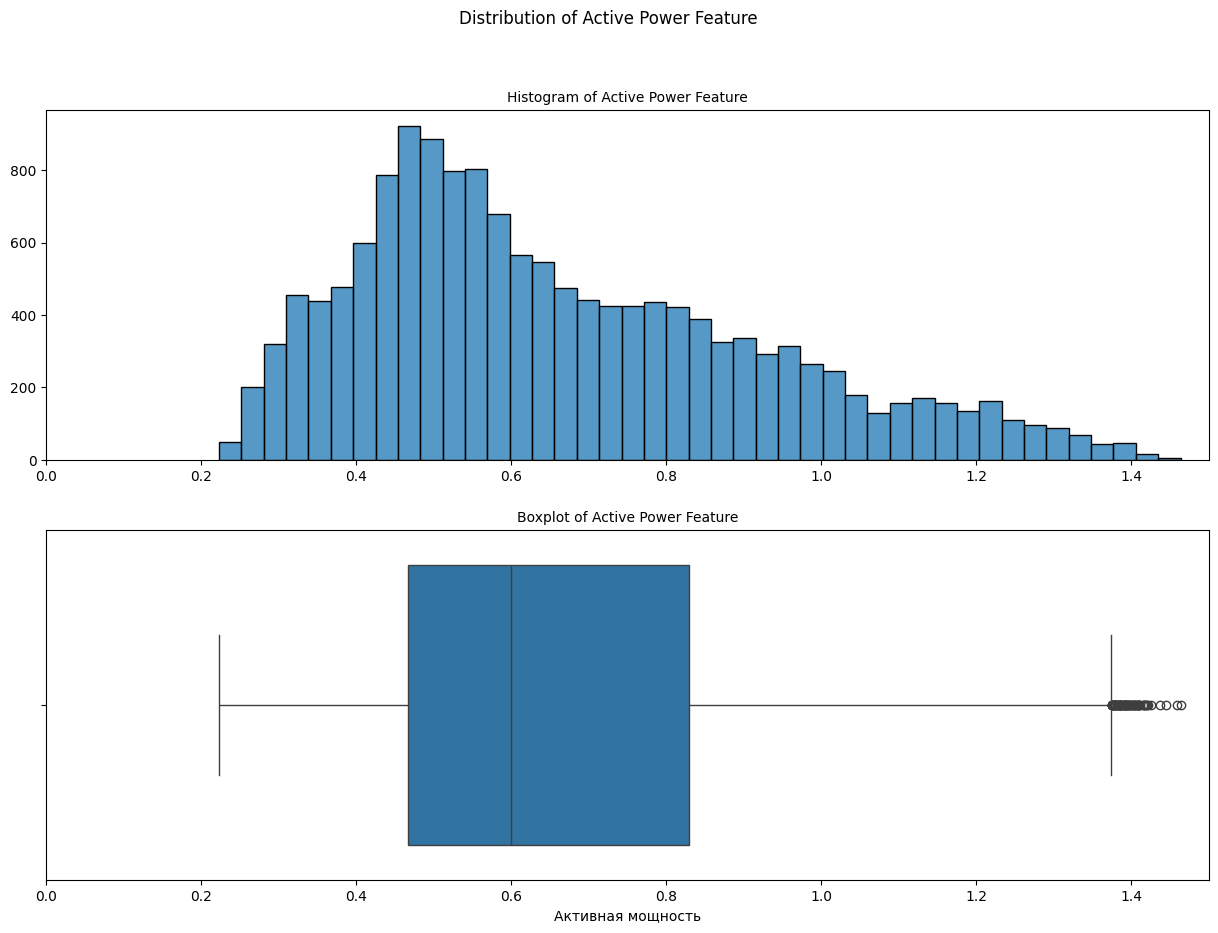

In [7]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Active Power Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(arc['Активная мощность'], kde=False)
plt.xlim(0, 1.5)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Active Power Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(arc['Активная мощность'], orient='h')
plt.xlim(0, 1.5)
plt.title('Boxplot of Active Power Feature', fontsize=10)

plt.show()

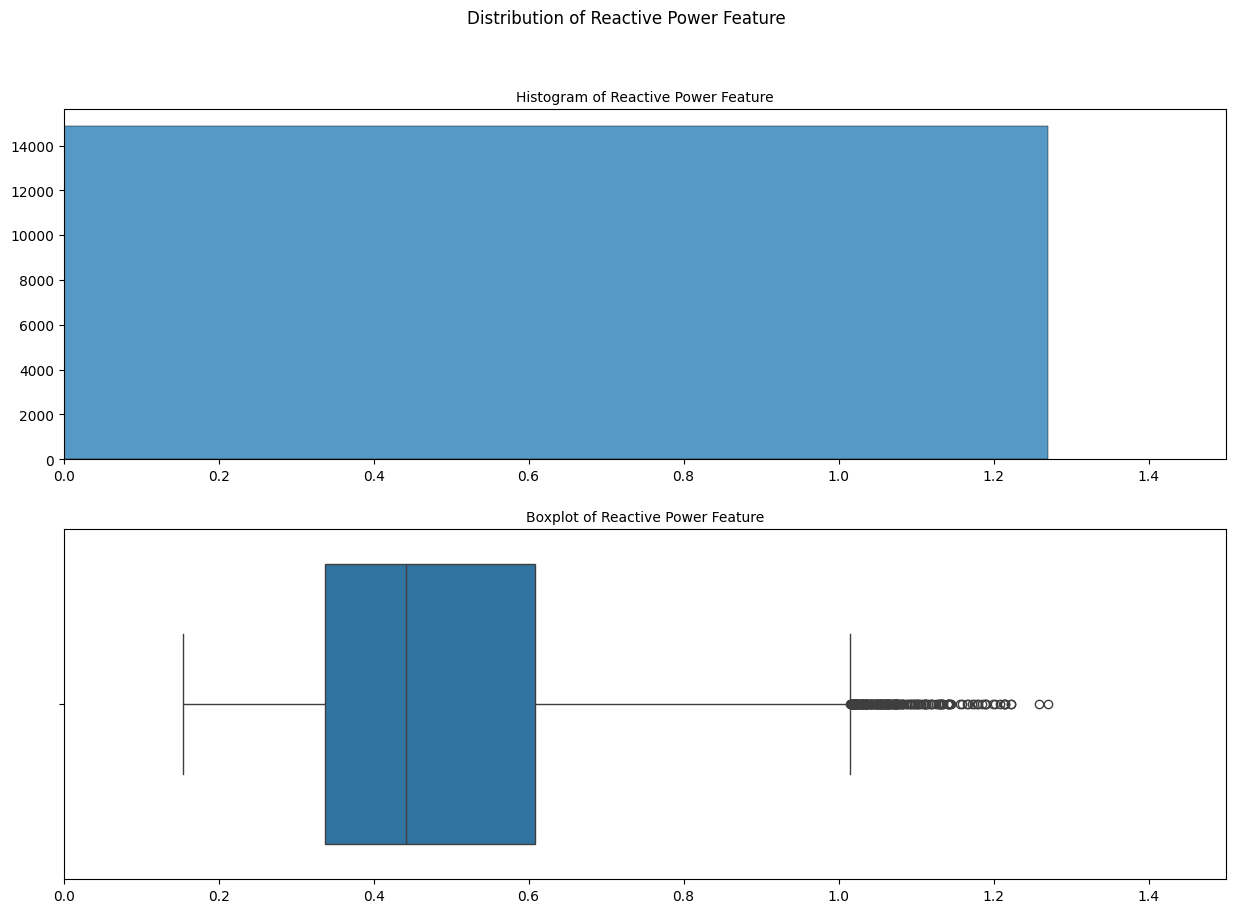

Minimum Reactive Power value after excluding outlier: 0.153777


In [8]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Reactive Power Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(arc['Реактивная мощность'], kde=False)
plt.xlim(0, 1.5)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Reactive Power Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(arc['Реактивная мощность'], orient='h')
plt.xlim(0, 1.5)
plt.xlabel('')
plt.title('Boxplot of Reactive Power Feature', fontsize=10)

plt.show()

print(f'Minimum Reactive Power value after excluding outlier: {arc["Реактивная мощность"].nsmallest(2).iloc[-1]}')

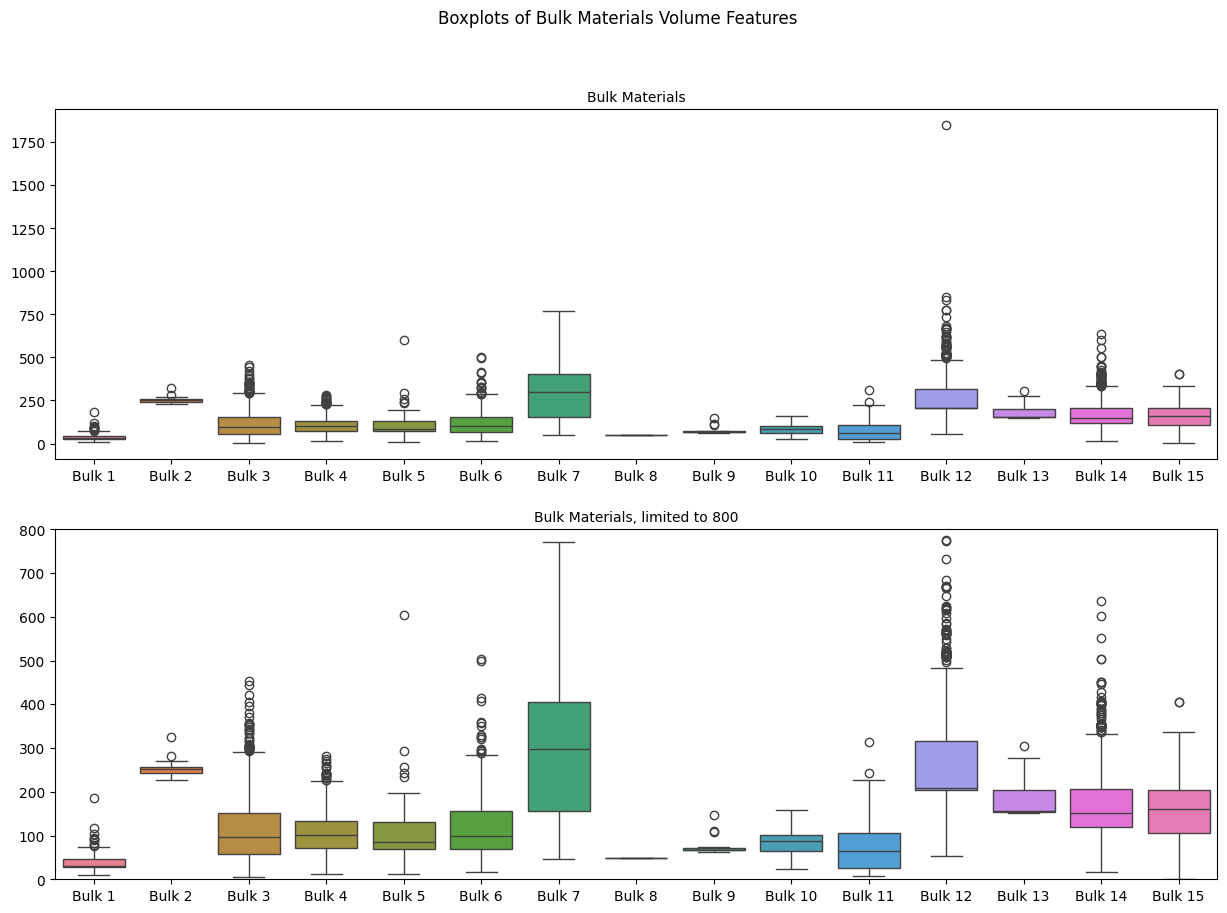

In [9]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Bulk Materials Volume Features')

ax = plt.subplot(2, 1, 1)
plt.title('Bulk Materials', fontsize=10)
sns.boxplot(data=bulk.loc[:, 'Bulk 1':'Bulk 15'])

ax = plt.subplot(2, 1, 2)
plt.title('Bulk Materials, limited to 800', fontsize=10)
sns.boxplot(data=bulk.loc[:, 'Bulk 1':'Bulk 15'])
plt.ylim(0, 800)

plt.show()

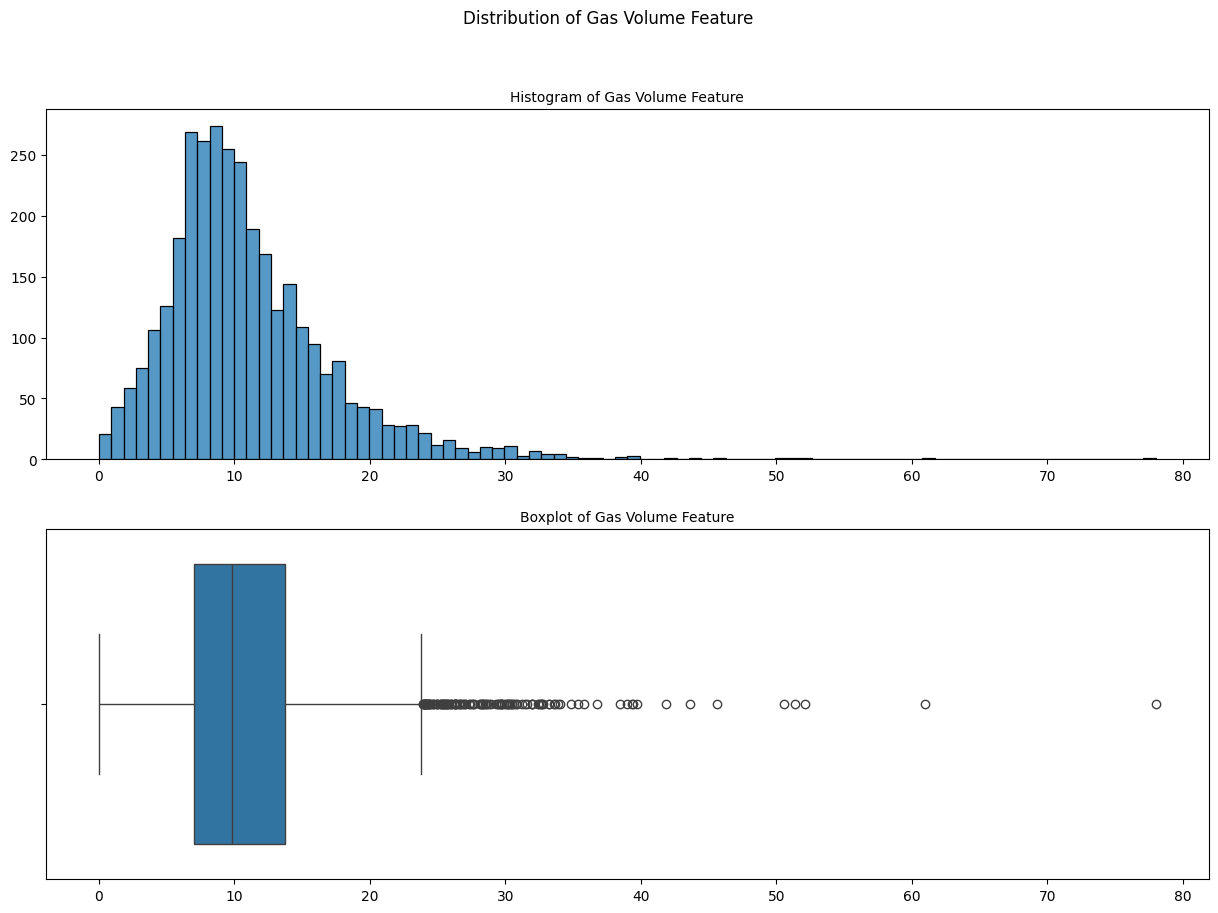

In [10]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Gas Volume Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(gas['Газ 1'], kde=False)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Gas Volume Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(gas['Газ 1'], orient='h')
plt.xlabel('')
plt.title('Boxplot of Gas Volume Feature', fontsize=10)

plt.show()

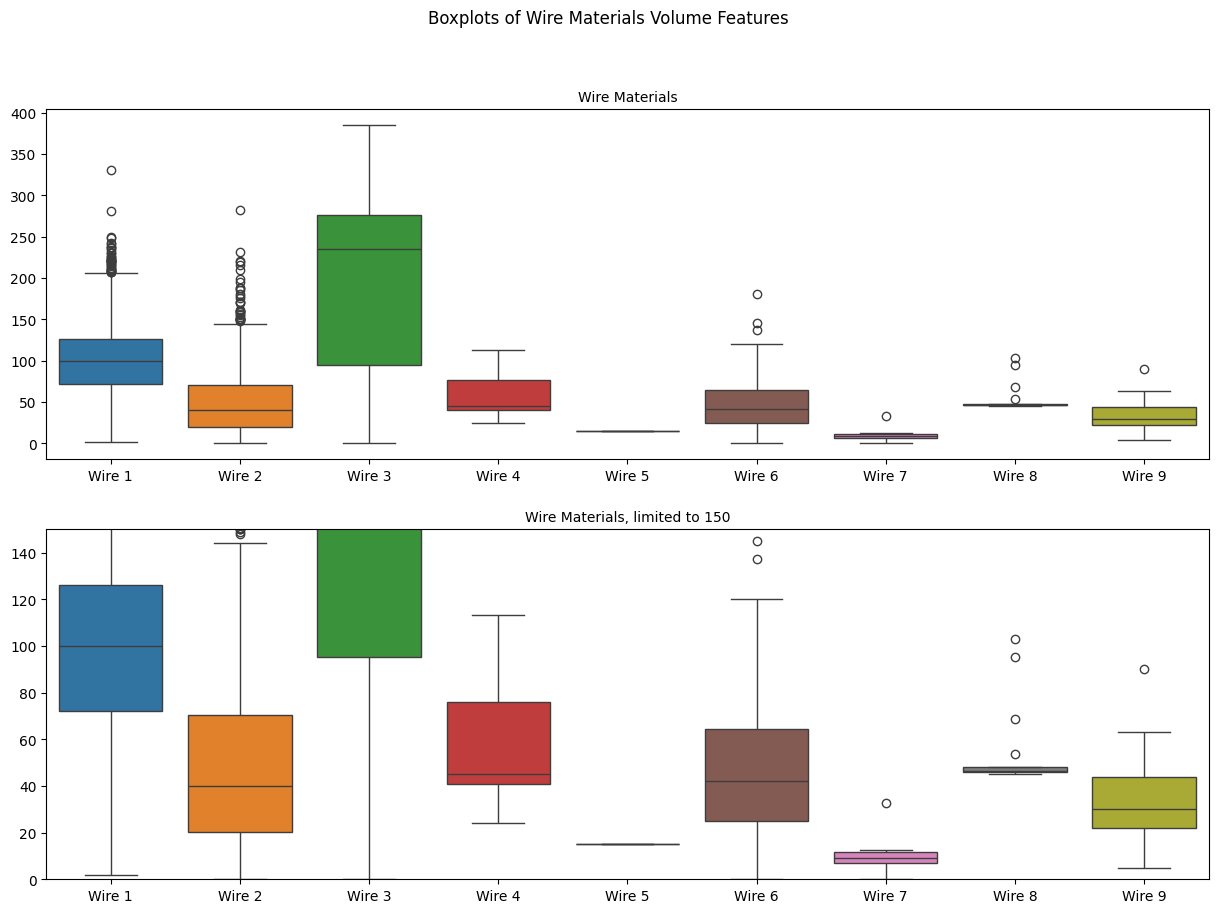

In [11]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Wire Materials Volume Features')

ax = plt.subplot(2, 1, 1)
plt.title('Wire Materials', fontsize=10)
sns.boxplot(data=wire.loc[:, 'Wire 1':'Wire 9'])

ax = plt.subplot(2, 1, 2)
plt.title('Wire Materials, limited to 150', fontsize=10)
sns.boxplot(data=wire.loc[:, 'Wire 1':'Wire 9'])
plt.ylim(0, 150)

plt.show()

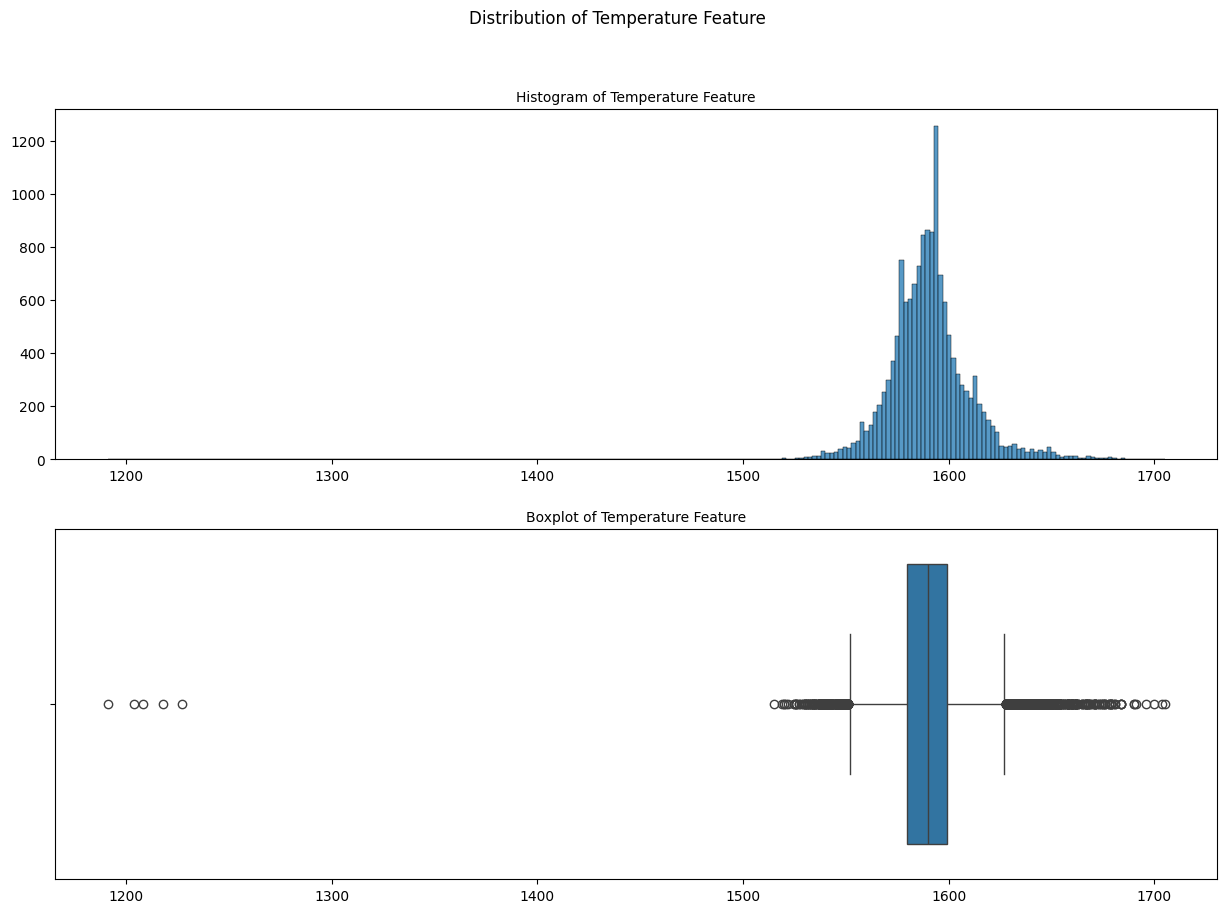

In [12]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Distribution of Temperature Feature')

ax = plt.subplot(2, 1, 1)
sns.histplot(temp['Температура'], kde=False)
plt.xlabel('')
plt.ylabel('')
plt.title('Histogram of Temperature Feature', fontsize=10)

ax = plt.subplot(2, 1, 2)
sns.boxplot(temp['Температура'], orient='h')
plt.xlabel('')
plt.title('Boxplot of Temperature Feature', fontsize=10)

plt.show()

<h4>1.3.3. Conclusion</h4>


The data is contained in 7 datasets:<br>

- arc dataset - data on power used for alloy heating;<br>
  The dataset contains 14876 records for 3214 unique batch numbers (key), each key may correspond to multiple records.<br>
  No duplicate records, incorrect data type for heating start and end (object instead of datetime).<br>
  Active Power values range from 0.22 to 1.46, median value is 0.6, distribution has a heavy right tail.<br>
  Reactive Power values have an outlier of -715.5, excluding the outlier, values range from 0.15 to 1.27, median value is 0.4, distribution has a heavy right tail.<br>

- bulk dataset - data on bulk materials volumes added to the alloy;<br>
  The dataset contains 3129 records for 3129 unique batch numbers (key), each key corresponds to one record, and 15 types of materials.<br>
  No duplicate records, data types are correct, there are missing NaN values (most likely, material was not added).<br>
  Bulk materials volume values are heterogeneous across materials: minimum values from 1 (Bulk 15) to 228 (Bulk 2), maximum values from 49 (Bulk 8) to 1849 (Bulk 12, possibly an outlier). Bulk materials addition frequency is also heterogeneous: Bulk 8 was added to 1 batch, while Bulk 15 was added to 2806 batches.<br>

- bulk_time dataset - data on bulk materials addition time;<br>
  The dataset contains 3129 records for 3129 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are incorrect (object instead of datetime), there are missing NaN values (material was not added).<br>

- gas dataset - data on gas volume added to the alloy;<br>
  The dataset contains 3239 records for 3239 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are correct, there are missing NaN values (material was not added).<br>
  Gas volume values range from 0.008 to 78 (possibly an outlier), median value is 9.8.<br>
  
- wire dataset - data on wire materials volumes added to the alloy;<br>
  The dataset contains 3081 records for 3081 unique batch numbers (key), each key corresponds to one record, and 9 types of materials.<br>
  No duplicate records, data types are correct, there are missing NaN values (most likely, material was not added).<br>
  Wire materials volume values are heterogeneous across materials: minimum values from 0.03 (Wire 2) to 45.1 (Wire 8), maximum values from 15.1 (Wire 5) to 385 (Wire 3). Wire materials addition frequency is also heterogeneous: Wire 5 was added to 1 batch, while Wire 1 was added to 3055 batches.<br>

- wire_time dataset - data on wire materials addition time;<br>
  The dataset contains 3081 records for 3081 unique batch numbers (key), each key corresponds to one record.<br>
  No duplicate records, data types are incorrect (object instead of datetime), there are missing NaN values (material was not added).<br>

- temp dataset - data on alloy temperature measurements.<br>
  The dataset contains 18092 records for 3216 unique batch numbers (key), each key may correspond to multiple records.<br>
  Each batch has initial temperature data, subsequent measurements may or may not be present. There are records with only the first temperature measurement.<br>
  No duplicate records, incorrect data type for measurement time (object instead of datetime).<br>
  Temperature values range from 1191 to 1705, median value is 1590, there are outliers in the data (alloy temperature cannot be below 1500).<br>

Next steps for data preprocessing:<br>
- Rename features (English language, lowercase);<br>
- Change data types (heating start and end features in arc dataset, temperature measurement time);<br>
- Exclude irrelevant material addition time data from further analysis;<br>
- Handle outliers (reactive power value of -715.5 in arc dataset, first and last temperature measurements below 1500 in temp dataset);<br> 
- Identify atypical values for bulk, wire materials volumes and gas;<br>
- Generate additional features;<br>
- Create a summary table where each record corresponds to one unique batch number key, with two temperature measurements (initial and final).<br>

<h3>1.4. Data Preprocessing</h3> 

<h4>1.4.1. Rename Features</h4> 

In [13]:
arc.columns = ['key', 'start_time','end_time', 
               'active_power', 'reactive_power']
gas.columns = ['key', 'gas']
temp.columns = ['key', 'time', 'temperature']
bulk.columns = ['key', 'bulk_1', 
                'bulk_2', 'bulk_3', 
                'bulk_4', 'bulk_5', 
                'bulk_6', 'bulk_7', 
                'bulk_8', 'bulk_9', 
                'bulk_10', 'bulk_11', 
                'bulk_12', 'bulk_13', 
                'bulk_14', 'bulk_15']
wire.columns = ['key', 'wire_1', 
                'wire_2', 'wire_3', 
                'wire_4', 'wire_5', 
                'wire_6', 'wire_7', 
                'wire_8', 'wire_9']

<h4>1.4.2. Change Data Types</h4> 

In [14]:
arc['start_time'] = pd.to_datetime(arc['start_time'])
arc['end_time'] = pd.to_datetime(arc['end_time'])
temp['time'] = pd.to_datetime(temp['time'])

<h4>1.4.3. Handle Data Outliers</h4> 

In [15]:
# Remove reactive_power outlier
arc = arc[arc['reactive_power']>=0]

In [16]:
# Remove temperature outliers

# Sort temp data by time to ensure correct first/last aggregation
temp_sorted = temp.sort_values(['key', 'time'])

# Create pivot table with temperature measurement count, first and last measurements for each key
temp_pt = temp_sorted.pivot_table(index='key', 
                           values=['time', 'temperature'], 
                           aggfunc={'time': ['first', 'last'], 
                                    'temperature': ['first', 'last', 'count']}
                          )
# Rename pivot table columns
temp_pt.columns = [f'{agg}_{col}' for col, agg in temp_pt.columns]
# Remove outliers: temperatures less than 1500, keys with temperature measurement count less than 1
temp_pt = temp_pt[(temp_pt['count_temperature']>1) 
                  & (temp_pt['first_temperature']>=1500) 
                  & (temp_pt['last_temperature']>1500)]

# Calculate average number of unique keys per day
keys_per_day = temp_pt.groupby(pd.to_datetime(temp_pt['first_time']).dt.date).size()
avg_keys_per_day = keys_per_day.mean()
print(f'Average number of unique keys per day: {avg_keys_per_day:.2f}')

# Calculate average temperature difference from target temperature (1600°C)
# Using last_temperature which is the final measurement from the last heating session
# Only consider positive differences (when temperature exceeded target)
temp_diff = temp_pt['last_temperature'] - 1600
avg_temp_diff = temp_diff[temp_diff > 0].mean()
print(f'Average positive temperature difference from target (1600°C): {avg_temp_diff:.2f}')

# Check
display(temp_pt.head())
display(temp_pt.info())
display(temp_pt.describe())

Average number of unique keys per day: 25.74
Average positive temperature difference from target (1600°C): 17.69


,count_temperature,first_temperature,last_temperature,first_time,last_time
key,,,,,
1,6,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
2,5,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
3,6,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
4,5,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
5,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39


<class 'pandas.DataFrame'>
Index: 2471 entries, 1 to 2499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   count_temperature  2471 non-null   int64         
 1   first_temperature  2471 non-null   float64       
 2   last_temperature   2471 non-null   float64       
 3   first_time         2471 non-null   datetime64[us]
 4   last_time          2471 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(1)
memory usage: 115.8 KB


None

,count_temperature,first_temperature,last_temperature,first_time,last_time
count,2471.000000,2471.000000,2471.000000,2471,2471
mean,5.626467,1589.012950,1595.339943,2019-06-20 23:55:28.544314,2019-06-21 00:33:29.861999
min,2.000000,1519.000000,1541.000000,2019-05-03 11:02:04,2019-05-03 11:30:38
25%,5.000000,1572.000000,1587.000000,2019-05-27 08:16:38.500000,2019-05-27 08:43:46.500000
50%,5.000000,1588.000000,1593.000000,2019-06-19 19:45:11,2019-06-19 20:15:27
75%,7.000000,1605.000000,1599.000000,2019-07-11 22:13:21,2019-07-11 22:55:15
max,17.000000,1679.000000,1700.000000,2019-08-10 13:33:21,2019-08-10 13:58:58
std,1.609465,25.004369,16.035215,NaN,NaN


<h4>1.4.4. Generate New Features</h4> 

In [17]:
# Create new features based on temp dataset

# Calculate production phase duration in seconds for each key
temp_pt['duration_phase'] = (temp_pt['last_time'] - temp_pt['first_time']).dt.total_seconds()

# Drop first_time and last_time features
temp_pt = temp_pt.drop(['first_time', 'last_time'], axis=1)

# Check
temp_pt.head()

,count_temperature,first_temperature,last_temperature,duration_phase
key,,,,
1,6,1571.0,1613.0,1714.0
2,5,1581.0,1602.0,1265.0
3,6,1596.0,1599.0,1753.0
4,5,1601.0,1625.0,1220.0
5,5,1576.0,1602.0,1536.0


In [18]:
# Create new features based on arc dataset

# Calculate duration of each heating in seconds
arc['heat_duration'] = (arc['end_time'] - arc['start_time']).dt.total_seconds()

# Create pivot table with measurement count, first and last measurements for each key
arc_pt = arc.pivot_table(index='key', 
                           values=['active_power', 'reactive_power', 'heat_duration'], 
                           aggfunc={'active_power': ['count', 'mean'], 
                                    'reactive_power': ['mean'],
                                    'heat_duration': ['mean', 'sum']}
                          )
# Rename pivot table columns
arc_pt.columns = [f'{agg}_{col}' for col, agg in arc_pt.columns]

# Calculate apparent power for each key
arc_pt['apparent_power'] = np.sqrt(arc_pt['mean_active_power']**2 + arc_pt['mean_reactive_power']**2)

# Calculate power factor for each key
arc_pt['power_factor'] = arc_pt['mean_active_power'] / arc_pt['apparent_power']

# Calculate work for each key
arc_pt['work'] = arc_pt['mean_active_power'] * arc_pt['sum_heat_duration']

# Check
display(arc_pt.head())
display(arc_pt.info())
display(arc_pt.describe())

,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,power_factor,work
key,,,,,,,,
1,5,0.607346,219.60,1098.0,0.428564,0.743328,0.817063,666.865908
2,4,0.534852,202.75,811.0,0.363339,0.646593,0.827185,433.764972
3,5,0.812728,131.00,655.0,0.587491,1.002833,0.810433,532.336971
4,4,0.676622,185.25,741.0,0.514248,0.849864,0.796154,501.377087
5,4,0.563238,217.25,869.0,0.421998,0.703789,0.800293,489.453388


<class 'pandas.DataFrame'>
Index: 3214 entries, 1 to 3241
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   count_active_power   3214 non-null   int64  
 1   mean_active_power    3214 non-null   float64
 2   mean_heat_duration   3214 non-null   float64
 3   sum_heat_duration    3214 non-null   float64
 4   mean_reactive_power  3214 non-null   float64
 5   apparent_power       3214 non-null   float64
 6   power_factor         3214 non-null   float64
 7   work                 3214 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 226.0 KB


None

,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,power_factor,work
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,4.628189,0.661327,172.339212,794.545115,0.485972,0.820930,0.805813,527.013185
std,1.608866,0.128372,45.606776,332.491076,0.097586,0.159995,0.014563,244.571363
min,1.000000,0.267676,57.000000,57.000000,0.196228,0.331897,0.739778,26.187544
25%,4.000000,0.573035,140.000000,571.000000,0.417415,0.710370,0.796620,361.696484
50%,4.000000,0.652732,168.750000,770.000000,0.481639,0.812019,0.806655,499.313525
75%,6.000000,0.739388,200.383333,983.000000,0.543312,0.916261,0.815816,668.321506
max,16.000000,1.243889,380.000000,4189.000000,0.960763,1.571727,0.857042,3456.102614


<h4>1.4.5. Create Final Dataset for Further Analysis</h4> 

In [19]:
# Merge datasets by key
df = temp_pt.merge(arc_pt, on='key', how='inner')\
                .merge(bulk, on='key', how='inner')\
                    .merge(wire, on='key', how='inner')\
                        .merge(gas, on='key', how='inner')\
                            .set_index('key', drop=True)

# Check
display(df.head())
display(df.info())
display(df.describe())

,count_temperature,first_temperature,last_temperature,duration_phase,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
1,6,1571.0,1613.0,1714.0,5,0.607346,219.60,1098.0,0.428564,0.743328,...,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.749986
2,5,1581.0,1602.0,1265.0,4,0.534852,202.75,811.0,0.363339,0.646593,...,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.555561
3,6,1596.0,1599.0,1753.0,5,0.812728,131.00,655.0,0.587491,1.002833,...,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.554793
4,5,1601.0,1625.0,1220.0,4,0.676622,185.25,741.0,0.514248,0.849864,...,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.841219
5,5,1576.0,1602.0,1536.0,4,0.563238,217.25,869.0,0.421998,0.703789,...,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.413692


<class 'pandas.DataFrame'>
Index: 2325 entries, 1 to 2499
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   count_temperature    2325 non-null   int64  
 1   first_temperature    2325 non-null   float64
 2   last_temperature     2325 non-null   float64
 3   duration_phase       2325 non-null   float64
 4   count_active_power   2325 non-null   int64  
 5   mean_active_power    2325 non-null   float64
 6   mean_heat_duration   2325 non-null   float64
 7   sum_heat_duration    2325 non-null   float64
 8   mean_reactive_power  2325 non-null   float64
 9   apparent_power       2325 non-null   float64
 10  power_factor         2325 non-null   float64
 11  work                 2325 non-null   float64
 12  bulk_1               199 non-null    float64
 13  bulk_2               13 non-null     float64
 14  bulk_3               958 non-null    float64
 15  bulk_4               811 non-null    float64
 16  bulk

None

,count_temperature,first_temperature,last_temperature,duration_phase,count_active_power,mean_active_power,mean_heat_duration,sum_heat_duration,mean_reactive_power,apparent_power,...,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,gas
count,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,...,2302.000000,809.000000,39.000000,12.000000,0.0,45.000000,4.000000,13.000000,24.000000,2325.000000
mean,5.696344,1587.365161,1593.366022,2323.419785,4.695914,0.664200,172.090546,807.988387,0.488928,0.824996,...,103.435430,50.597164,193.182538,59.496235,NaN,50.659374,3.703414,55.772561,30.773167,11.378942
std,1.605930,23.623144,11.209581,1385.569302,1.606250,0.128392,43.751270,340.888430,0.098004,0.160257,...,42.525047,39.800935,100.867783,30.804638,NaN,37.743040,3.818433,20.235591,15.210141,6.395632
min,2.000000,1519.000000,1541.000000,339.000000,1.000000,0.267676,57.000000,57.000000,0.196228,0.331897,...,1.918800,0.030160,0.144144,24.148801,NaN,0.137280,0.234208,45.076721,4.622800,0.008399
25%,5.000000,1571.000000,1587.000000,1581.000000,4.000000,0.576249,141.000000,581.000000,0.420051,0.713724,...,75.042236,20.180161,93.189102,38.347402,NaN,25.053600,0.849004,46.002319,20.802601,7.282948
50%,6.000000,1587.000000,1593.000000,2046.000000,5.000000,0.655642,169.500000,778.000000,0.484690,0.817669,...,102.030235,40.112801,236.972740,49.661561,NaN,40.085762,3.044704,46.187439,30.066399,10.100950
75%,7.000000,1603.000000,1598.000000,2793.000000,6.000000,0.741868,198.750000,993.000000,0.546687,0.920695,...,128.178188,70.061684,277.068801,84.755579,NaN,65.036400,5.899114,46.279999,40.495001,14.217691
max,17.000000,1660.000000,1653.000000,23674.000000,16.000000,1.243889,378.000000,4189.000000,0.960763,1.571727,...,330.314424,282.780152,385.008668,113.231044,NaN,180.454575,8.490040,102.762401,62.025600,77.995040


<h4>1.4.6. Correlation Analysis</h4> 

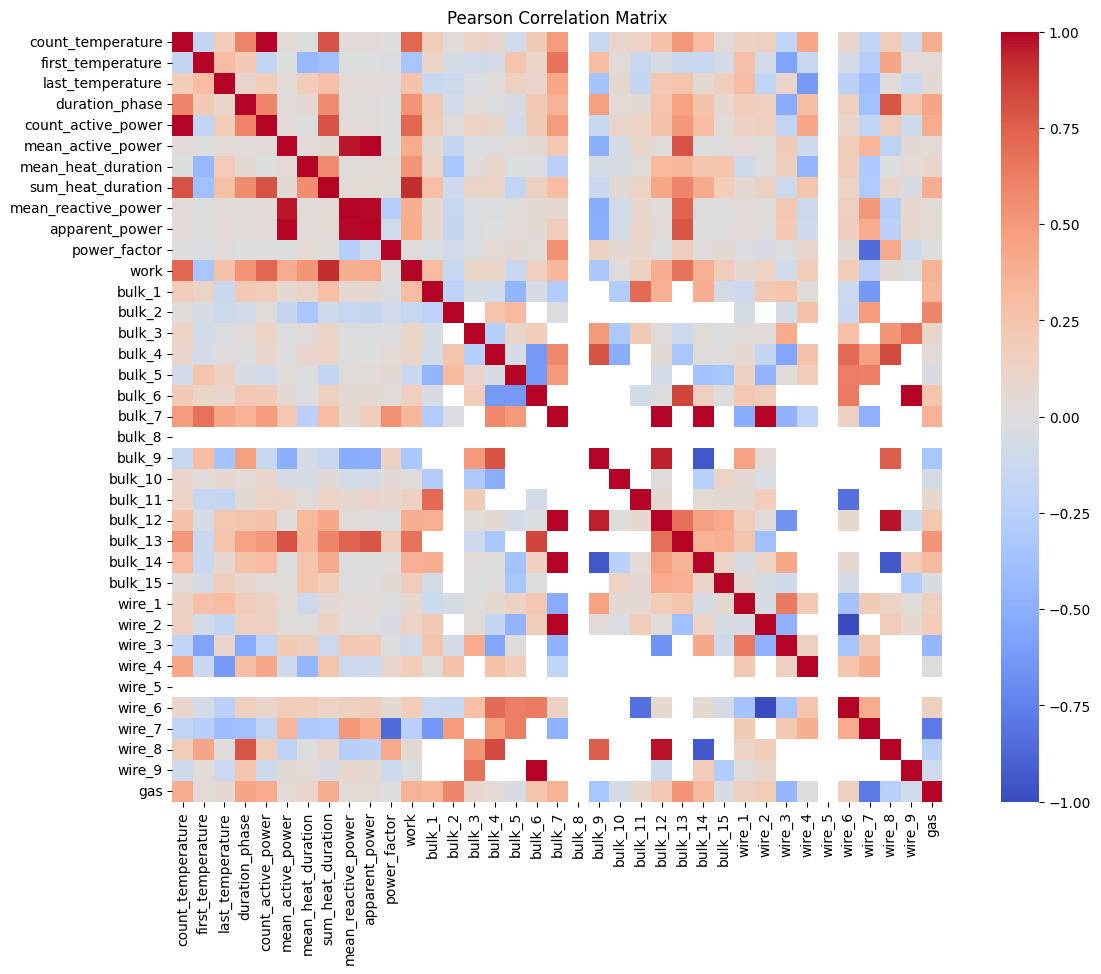

In [20]:
# Create correlation matrix

corr = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

In [21]:
df = df.fillna(0)

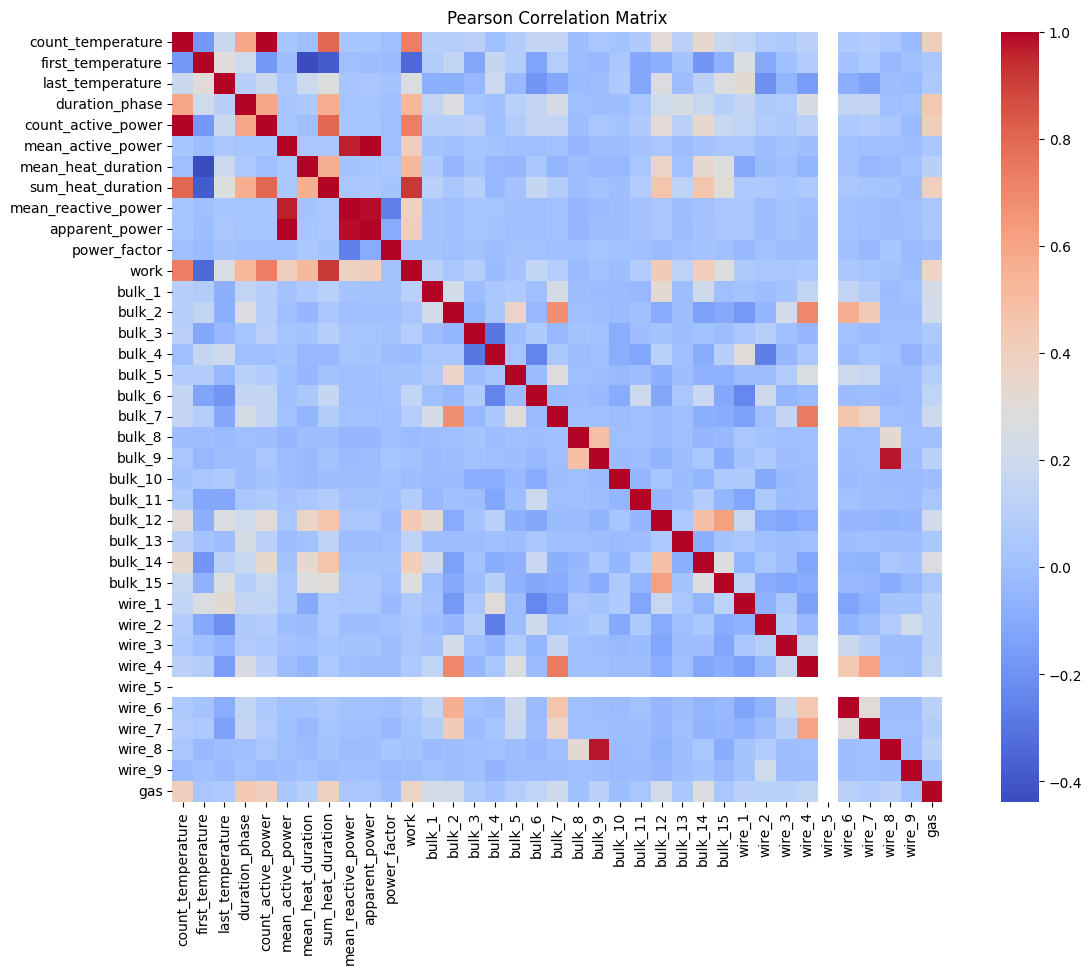

In [22]:
corr = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

Conclusion: <br>
In the final dataset: 
- features calculated based on power logically correlate with each other (upper left corner);
- some material volume features ('bulk_2', 'bulk_7', 'bulk_9', 'bulk_13', 'wire_4', 'wire_5', 'wire_8') contain insufficient observations for correlation calculation, additionally there are cases of strong positive and strong negative correlation between materials (lower right corner);
- after preprocessing, feature 'bulk_8' contains very few observations (1), feature 'wire_5' contains no observations.

For further analysis it is necessary to: <br>
- exclude features 'bulk_8' and 'wire_5';
- exclude highly correlated features calculated based on power;
- to avoid multicollinearity problems in the model, use a linear model with regularization (Ridge Regression) or non-linear models.

In [23]:
# Drop empty features
df = df.drop(['bulk_8', 'wire_5'], 
              axis=1
            )

# Drop correlated features
df = df.drop(['mean_active_power', 'mean_reactive_power', 
              'count_active_power', 'mean_heat_duration'], 
              axis=1
            )

# Replace NaN with 0


# Check
display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
Index: 2325 entries, 1 to 2499
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   count_temperature  2325 non-null   int64  
 1   first_temperature  2325 non-null   float64
 2   last_temperature   2325 non-null   float64
 3   duration_phase     2325 non-null   float64
 4   sum_heat_duration  2325 non-null   float64
 5   apparent_power     2325 non-null   float64
 6   power_factor       2325 non-null   float64
 7   work               2325 non-null   float64
 8   bulk_1             2325 non-null   float64
 9   bulk_2             2325 non-null   float64
 10  bulk_3             2325 non-null   float64
 11  bulk_4             2325 non-null   float64
 12  bulk_5             2325 non-null   float64
 13  bulk_6             2325 non-null   float64
 14  bulk_7             2325 non-null   float64
 15  bulk_9             2325 non-null   float64
 16  bulk_10            2325 non-null   float

None

,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
1,6,1571.0,1613.0,1714.0,1098.0,0.743328,0.817063,666.865908,0.0,0.0,...,154.0,60.059998,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,29.749986
2,5,1581.0,1602.0,1265.0,811.0,0.646593,0.827185,433.764972,0.0,0.0,...,154.0,96.052315,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,12.555561
3,6,1596.0,1599.0,1753.0,655.0,1.002833,0.810433,532.336971,0.0,0.0,...,153.0,91.160157,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,28.554793
4,5,1601.0,1625.0,1220.0,741.0,0.849864,0.796154,501.377087,0.0,0.0,...,154.0,89.063515,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,18.841219
5,5,1576.0,1602.0,1536.0,869.0,0.703789,0.800293,489.453388,0.0,0.0,...,152.0,89.238236,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,5.413692


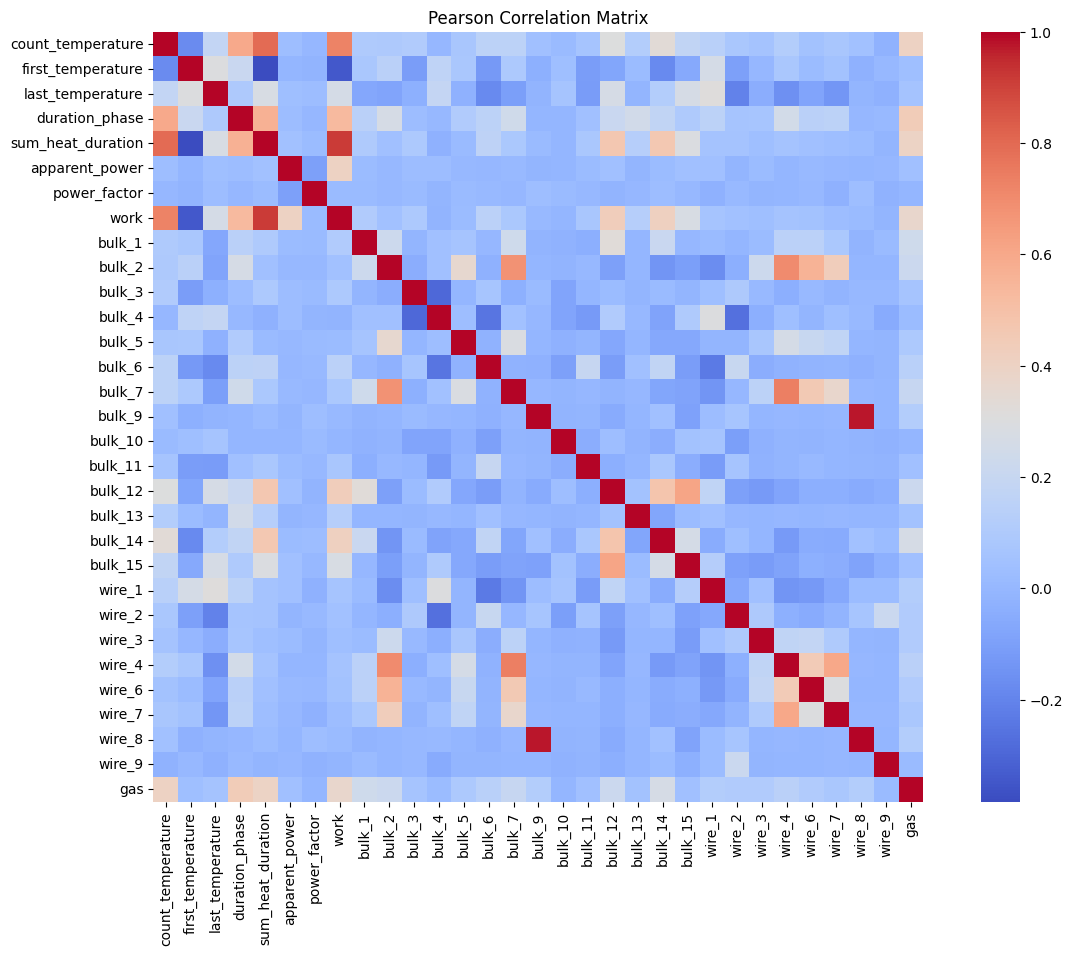

In [24]:
corr_new = df.corr(method='pearson')
plt.figure(figsize=(15, 10))
sns.heatmap(corr_new, 
            annot=False, 
            cmap='coolwarm', 
            cbar=True, 
            square=True)
plt.title('Pearson Correlation Matrix')
plt.show()

<h4>1.4.7. Identify Atypical Values</h4> 

In [25]:
# Check outliers in the entire dataset

data = df.copy().reset_index()

# Find outliers using KNN model
knn = KNN()
estimation_knn = knn.fit_predict(data)
num_outliers_knn = np.int64(len(estimation_knn[estimation_knn == 1]))
print(f'Number of outliers (KNN): {num_outliers_knn}')

# Find outliers using Isolation Forest model
iforest = IsolationForest(n_estimators=100, random_state=31123)
estimation_iforest = iforest.fit_predict(data)
num_outliers_iforest = np.int64(len(data) - len(estimation_iforest[estimation_iforest == -1]))
print(f'Number of outliers (Isolation Forest): {num_outliers_iforest}')

# Create dataframe with outliers found by both models
knn_outliers_indices = np.where(estimation_knn == 1)[0]
iforest_outliers_indices = np.where(estimation_iforest == -1)[0]
outliers_indices = np.intersect1d(knn_outliers_indices, iforest_outliers_indices)
print(f'Number of outliers (both models): {len(outliers_indices)}')

Number of outliers (KNN): 233
Number of outliers (Isolation Forest): 2287
Number of outliers (both models): 36


In [26]:
# Outliers
outliers = data[data.index.isin(outliers_indices)].set_index('key', drop=True)

display(outliers.head())
display(outliers.describe())

display(outliers[outliers['bulk_12']>1700])
display(outliers[outliers['gas']>70])

,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
44,13,1600.0,1603.0,10976.0,2063.0,0.747851,0.813330,1254.819062,0.0,0.0,...,159.0,69.189123,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,21.265271
45,11,1538.0,1621.0,4887.0,2136.0,0.775724,0.808571,1339.759222,0.0,0.0,...,204.0,114.354237,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,18.601690
46,14,1607.0,1612.0,12323.0,2919.0,0.890473,0.793033,2061.321232,0.0,0.0,...,204.0,100.245593,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,6.118441
113,5,1645.0,1647.0,4550.0,819.0,0.982532,0.831254,668.904941,0.0,228.0,...,0.0,7.556640,0.0,96.047951,24.148801,60.094322,0.0,0.0,0.0,25.377930
114,4,1631.0,1600.0,4731.0,519.0,0.560224,0.779058,226.515993,0.0,247.0,...,0.0,0.000000,0.0,88.648567,43.065361,54.122643,0.0,0.0,0.0,14.683228


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,9.055556,1607.500000,1593.138889,8196.972222,1506.000000,0.833900,0.806953,1038.103641,24.777778,92.027778,...,85.916667,94.009412,36.239522,31.167137,16.271869,23.975382,0.411490,1.277842,2.637989,27.256830
std,3.748862,33.443769,26.568674,5449.470766,884.456896,0.146212,0.013343,668.386831,38.820548,125.072890,...,103.650891,83.362002,69.084775,44.664305,30.301398,34.250894,1.625746,7.667053,11.176375,15.371763
min,2.000000,1520.000000,1541.000000,2690.000000,161.000000,0.484789,0.777527,78.265642,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.120463
25%,7.000000,1589.500000,1579.750000,3937.250000,817.750000,0.743825,0.801375,568.007377,0.000000,0.000000,...,0.000000,4.051320,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.242287
50%,9.000000,1618.000000,1600.000000,7001.500000,1409.500000,0.858422,0.809487,1040.788436,0.000000,0.000000,...,0.000000,99.153596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.147420
75%,11.250000,1629.500000,1612.500000,11155.000000,1959.500000,0.955350,0.816006,1276.054102,40.000000,242.000000,...,203.000000,162.629998,52.636738,93.080990,26.407162,60.042844,0.000000,0.000000,0.000000,32.736485
max,17.000000,1652.000000,1647.000000,23674.000000,4189.000000,1.041395,0.831254,3456.102614,185.000000,325.000000,...,337.000000,236.667587,282.780152,97.008911,113.231044,99.219122,8.490040,46.002319,55.000397,77.995040


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
322,14,1619.0,1616.0,7011.0,2658.0,0.851597,0.805257,1822.73495,185.0,0.0,...,0.0,0.0,188.22855,0.0,0.0,0.0,0.0,0.0,0.0,77.99504


,count_temperature,first_temperature,last_temperature,duration_phase,sum_heat_duration,apparent_power,power_factor,work,bulk_1,bulk_2,...,bulk_15,wire_1,wire_2,wire_3,wire_4,wire_6,wire_7,wire_8,wire_9,gas
key,,,,,,,,,,,,,,,,,,,,,
322,14,1619.0,1616.0,7011.0,2658.0,0.851597,0.805257,1822.73495,185.0,0.0,...,0.0,0.0,188.22855,0.0,0.0,0.0,0.0,0.0,0.0,77.99504


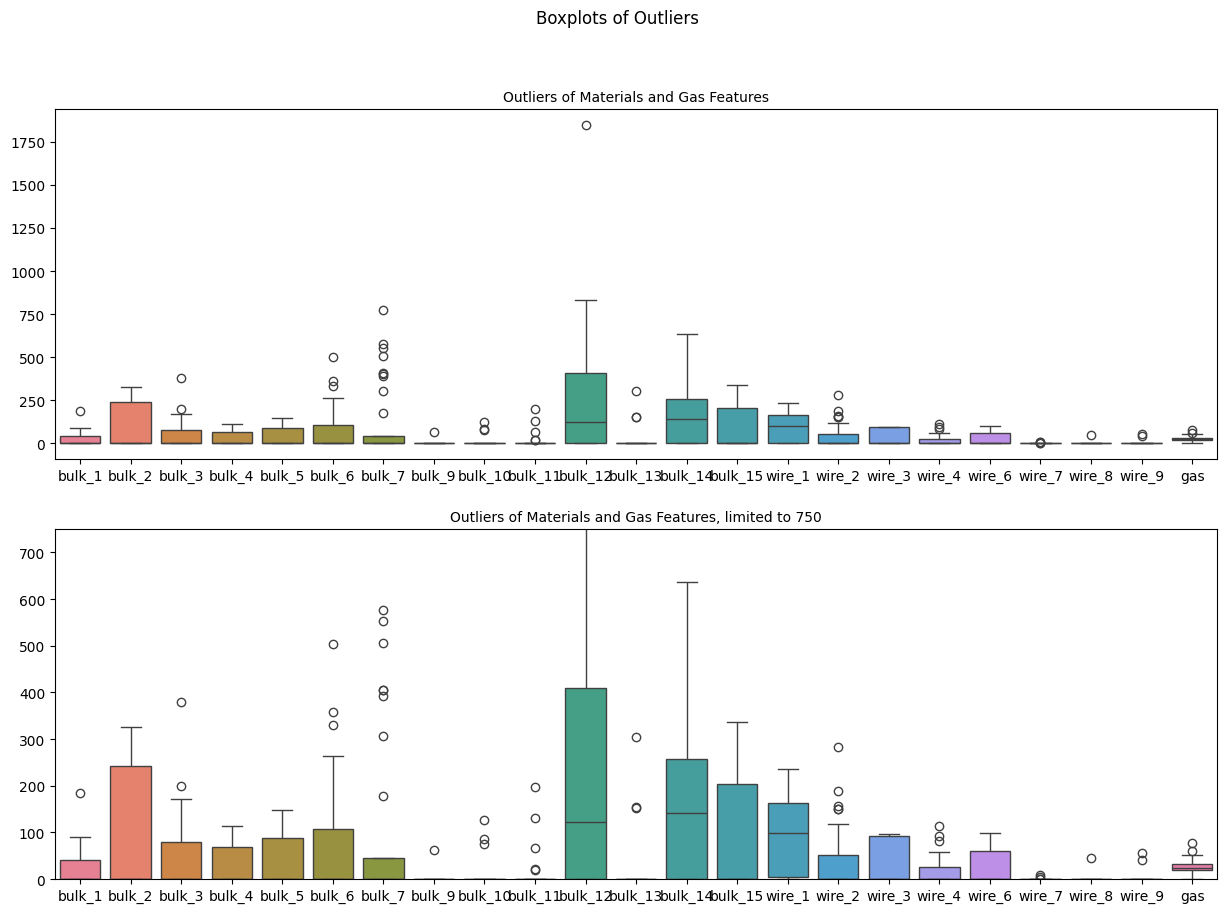

In [27]:
plt.figure(figsize=(15, 10))
plt.suptitle(f'Boxplots of Outliers')

ax = plt.subplot(2, 1, 1)
plt.title('Outliers of Materials and Gas Features', fontsize=10)
sns.boxplot(data=outliers.loc[:, 'bulk_1':'gas'])

ax = plt.subplot(2, 1, 2)
plt.title('Outliers of Materials and Gas Features, limited to 750', fontsize=10)
sns.boxplot(data=outliers.loc[:, 'bulk_1':'gas'])
plt.ylim(0, 750)

plt.show()

Conclusion: <br>
KNN and Isolation Forest models jointly found 36 records containing atypical values. The list of such values includes a batch with atypically high bulk_12 volume of 1849 and gas volume of 77.99 (these values were found during exploratory data analysis).
For further analysis, to improve model quality, the identified atypical records can be excluded from the training set. 

<h4>1.4.8. EDA Conclusion</h4> 

The final dataset created for further analysis contains 2325 records for 2325 batch numbers, each batch corresponds to one record.<br>
The final dataset includes features:
- count_temperature - number of temperature measurement iterations for the alloy batch;
- first_temperature - first temperature measurement value for the alloy batch;
- last_temperature - last temperature measurement value for the alloy batch (target feature);
- duration_phase - duration of this production phase for the alloy batch (in seconds);
- sum_heat_duration - total heating duration for the alloy batch (in seconds);
- apparent_power - apparent power for the alloy batch (square root of sum of squares of mean active power and mean reactive power);
- power_factor - average power factor for the alloy batch heating;
- work - work done for heating the alloy batch (product of mean active power and total heating duration in seconds);
- bulk_i - volumes of bulk material i additions to the alloy batch;
- wire_j - volumes of wire material j additions to the alloy batch;
- gas - gas volumes for the alloy batch.

<h2> Part 2. Modelling</h2> 

<h3>2.1. Preparation</h3> 

<h4>2.1.1. Fix Parameters</h4> 

In [28]:
RANDOM_STATE = 31123

<h4>2.1.2. Define Features</h4> 

In [29]:
y = df['last_temperature']
x = df.drop('last_temperature', axis=1)

<h4>2.1.3. Split Data into Training and Test Sets</h4> 

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y, 
                                                    test_size=0.25, 
                                                    random_state=RANDOM_STATE
                                                    )

print(f'Training set size: {x_train.shape, y_train.shape}')
print(f'Test set size: {x_test.shape, y_test.shape}')

Training set size: ((1743, 30), (1743,))
Test set size: ((582, 30), (582,))


In [31]:
x_train = x_train[~x_train.index.isin(outliers.index)]
y_train = y_train[~y_train.index.isin(outliers.index)]

print(f'Training set size: {x_train.shape, y_train.shape}')
print(f'Test set size: {x_test.shape, y_test.shape}')

Training set size: ((1717, 30), (1717,))
Test set size: ((582, 30), (582,))


<h3>2.2. Model Training</h3> 

<h4>2.2.1. Linear Model (Ridge Regression)</h4> 

In [32]:
interval_cols = [col for col, dtype in x.dtypes.items() if (dtype == 'int64' or dtype == 'float64')]

In [33]:
# Define objective function for Optuna
def objective_lr(trial, error_score='raise'):

    params_lr = {'alpha': trial.suggest_uniform('alpha', 0.0, 1.0),
                 'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'lsqr'])
                }
    model_lr = Ridge(**params_lr, random_state=RANDOM_STATE)

    pipe_lr = Pipeline(
                    [
                    ('transformation', ColumnTransformer(
                                            transformers=[
                                                ('scaler', StandardScaler(), interval_cols)
                                                ],
                                                remainder='passthrough',
                                                n_jobs=-1
                                                )
                    ), 
                    ('model', model_lr)
                    ]
                    )
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(pipe_lr, 
                             x_train, 
                             y_train, 
                             cv=kfold, 
                             scoring='neg_mean_absolute_error'
                             )
    mae_lr = -scores.mean()

    return mae_lr

In [34]:
%%time

# Create Optuna study
study_lr = optuna.create_study(direction='minimize')

# Optimize hyperparameters
study_lr.optimize(objective_lr, n_trials=100)

[I 2026-01-24 00:52:57,404] A new study created in memory with name: no-name-d55ba3e6-4742-4f45-b42f-c1131101e40e
[I 2026-01-24 00:53:08,386] Trial 0 finished with value: 5.667293292672541 and parameters: {'alpha': 0.4844555098315023, 'solver': 'lsqr'}. Best is trial 0 with value: 5.667293292672541.
[I 2026-01-24 00:53:18,658] Trial 1 finished with value: 5.667271273304402 and parameters: {'alpha': 0.6372308160911503, 'solver': 'lsqr'}. Best is trial 1 with value: 5.667271273304402.
[I 2026-01-24 00:53:20,844] Trial 2 finished with value: 5.6673211801897665 and parameters: {'alpha': 0.9442758652767592, 'solver': 'lsqr'}. Best is trial 1 with value: 5.667271273304402.
[I 2026-01-24 00:53:20,986] Trial 3 finished with value: 5.667892628279691 and parameters: {'alpha': 0.5766249734514185, 'solver': 'auto'}. Best is trial 1 with value: 5.667271273304402.
[I 2026-01-24 00:53:21,170] Trial 4 finished with value: 5.667762440087566 and parameters: {'alpha': 0.993627061097664, 'solver': 'svd'}.

CPU times: total: 5.52 s
Wall time: 38 s


In [35]:
# Return cross-validation MAE of Ridge Regression model
best_trial_lr = study_lr.best_trial
train_mae_lr = best_trial_lr.value

print(f'MAE of Ridge Regression on training set: {train_mae_lr:.5}')

MAE of Ridge Regression on training set: 5.6673


In [36]:
# Train Ridge Regression model with best hyperparameters
best_params_lr = study_lr.best_params
best_model_lr = Ridge(**best_params_lr)
best_model_lr.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.5697035879539307
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'lsqr'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gr

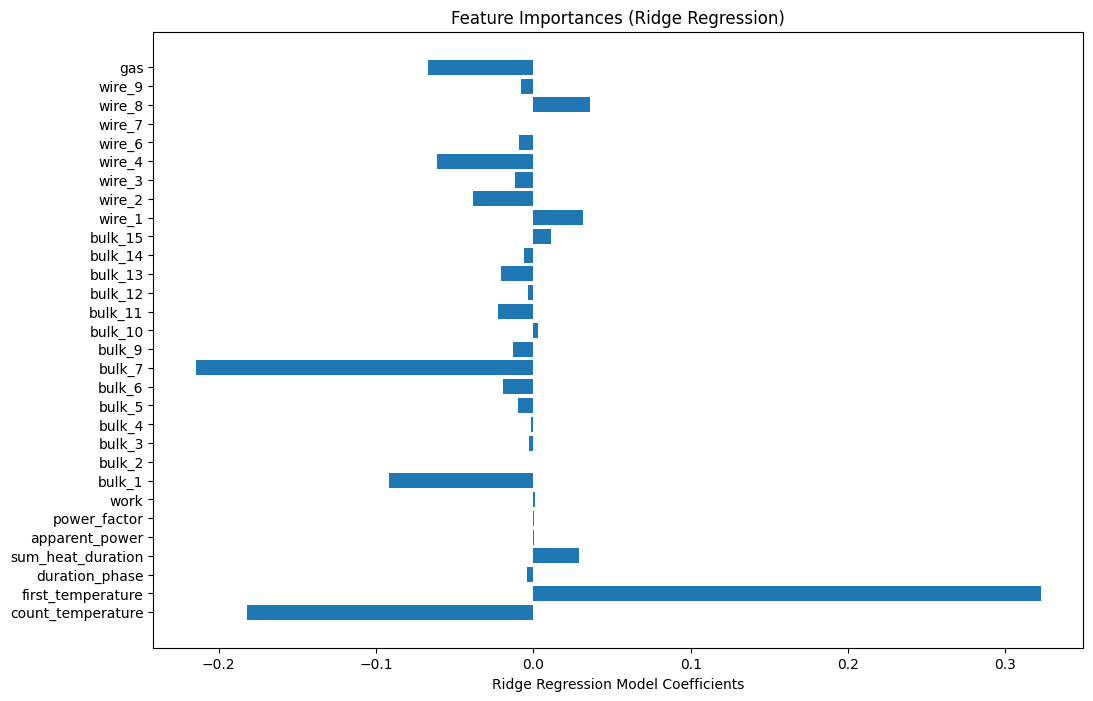

In [37]:
# Plot Ridge Regression coefficients
coef_lr = best_model_lr.coef_
feature_names = x_train.columns

plt.figure(figsize=(12, 8))
plt.barh(range(len(coef_lr)), coef_lr, tick_label=feature_names)
plt.xlabel('Ridge Regression Model Coefficients')
plt.title('Feature Importances (Ridge Regression)')
plt.show()

In [38]:
# Calculate MAE of Ridge Regression model on test set
y_test_pred_lr = best_model_lr.predict(x_test)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
print(f'MAE of Ringe Regression on test set: {test_mae_lr:.5}')

MAE of Ringe Regression on test set: 6.4674


<h4>2.2.2. Gradient Boosting Model (CatBoost Regressor)</h4> 

In [39]:
# Define objective function for Optuna
def objective_cb(trial):
    
    # Define hyperparameters to optimize
    params_cb = {'iterations': trial.suggest_int('iterations', 100, 1000),
                 'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
                 'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.01, 100),
                 'depth': trial.suggest_int('depth', 4, 10),
                 'loss_function': 'MAE',
                 'random_seed': RANDOM_STATE,
                 'verbose': 0,
                }
    
    train_pool = Pool(x_train, y_train)
    
    cv_results = cv(
        pool=train_pool,
        params=params_cb,
        fold_count=5,
        shuffle=True,
        partition_random_seed=RANDOM_STATE,
        verbose=False
    )
    
    # Get the best MAE from cross-validation (last iteration)
    mae_cb = cv_results['test-MAE-mean'].iloc[-1]
    
    # Handle NaN scores - return large value instead
    #if np.isnan(mae_cb):
    #    return float('inf')

    return mae_cb

In [40]:
%%time

# Create Optuna study
study_cb = optuna.create_study(direction='minimize')

# Optimize hyperparameters
study_cb.optimize(objective_cb, n_trials=200)

[I 2026-01-24 00:53:35,695] A new study created in memory with name: no-name-76dd8c43-438f-43a0-9c65-cea0b920f5a6


Training on fold [0/5]

bestTest = 27.88066906
bestIteration = 169

Training on fold [1/5]

bestTest = 38.15229521
bestIteration = 169

Training on fold [2/5]

bestTest = 38.92335612
bestIteration = 169

Training on fold [3/5]

bestTest = 33.79394388
bestIteration = 169

Training on fold [4/5]


[I 2026-01-24 00:53:49,367] Trial 0 finished with value: 34.256340971252726 and parameters: {'iterations': 170, 'learning_rate': 0.03695789817286073, 'l2_leaf_reg': 0.017999582374522264, 'depth': 10}. Best is trial 0 with value: 34.256340971252726.



bestTest = 32.53144058
bestIteration = 169

Training on fold [0/5]

bestTest = 15.48306212
bestIteration = 180

Training on fold [1/5]

bestTest = 18.92936483
bestIteration = 180

Training on fold [2/5]

bestTest = 19.0765703
bestIteration = 180

Training on fold [3/5]

bestTest = 20.69769946
bestIteration = 180

Training on fold [4/5]


[I 2026-01-24 00:53:54,062] Trial 1 finished with value: 17.492775447647933 and parameters: {'iterations': 181, 'learning_rate': 0.03903190687501952, 'l2_leaf_reg': 0.2719756471131957, 'depth': 8}. Best is trial 1 with value: 17.492775447647933.



bestTest = 13.27718053
bestIteration = 180

Training on fold [0/5]

bestTest = 26.44762755
bestIteration = 267

Training on fold [1/5]

bestTest = 36.7485438
bestIteration = 267

Training on fold [2/5]

bestTest = 37.92320476
bestIteration = 267

Training on fold [3/5]

bestTest = 32.6715311
bestIteration = 267

Training on fold [4/5]


[I 2026-01-24 00:54:14,953] Trial 2 finished with value: 32.915298828495416 and parameters: {'iterations': 268, 'learning_rate': 0.030458564125661645, 'l2_leaf_reg': 0.13309557451480933, 'depth': 10}. Best is trial 1 with value: 17.492775447647933.



bestTest = 30.78558694
bestIteration = 267

Training on fold [0/5]

bestTest = 12.01902171
bestIteration = 209

Training on fold [1/5]

bestTest = 15.36185766
bestIteration = 184

Training on fold [2/5]

bestTest = 14.03656071
bestIteration = 219

Training on fold [3/5]

bestTest = 11.88810686
bestIteration = 216

Training on fold [4/5]


[I 2026-01-24 00:54:18,395] Trial 3 finished with value: 12.776832920126825 and parameters: {'iterations': 220, 'learning_rate': 0.08780843672817785, 'l2_leaf_reg': 0.15702091601782162, 'depth': 7}. Best is trial 3 with value: 12.776832920126825.



bestTest = 10.51612733
bestIteration = 175

Training on fold [0/5]

bestTest = 14.18889032
bestIteration = 136

Training on fold [1/5]

bestTest = 17.59008008
bestIteration = 220

Training on fold [2/5]

bestTest = 16.92502245
bestIteration = 257

Training on fold [3/5]

bestTest = 21.10909327
bestIteration = 248

Training on fold [4/5]


[I 2026-01-24 00:54:24,604] Trial 4 finished with value: 16.800767790596467 and parameters: {'iterations': 258, 'learning_rate': 0.18872962823069245, 'l2_leaf_reg': 1.9998941288171788, 'depth': 8}. Best is trial 3 with value: 12.776832920126825.



bestTest = 14.02938755
bestIteration = 60

Training on fold [0/5]

bestTest = 6.184931389
bestIteration = 689

Training on fold [1/5]

bestTest = 7.22093998
bestIteration = 689

Training on fold [2/5]

bestTest = 6.800171435
bestIteration = 689

Training on fold [3/5]

bestTest = 6.604949376
bestIteration = 689

Training on fold [4/5]


[I 2026-01-24 00:54:28,234] Trial 5 finished with value: 6.690830596746321 and parameters: {'iterations': 690, 'learning_rate': 0.012687040283805693, 'l2_leaf_reg': 0.32730299131587554, 'depth': 4}. Best is trial 5 with value: 6.690830596746321.



bestTest = 6.643160803
bestIteration = 689

Training on fold [0/5]

bestTest = 6.711908221
bestIteration = 394

Training on fold [1/5]

bestTest = 8.030786779
bestIteration = 455

Training on fold [2/5]

bestTest = 10.61419824
bestIteration = 452

Training on fold [3/5]

bestTest = 7.088268016
bestIteration = 202

Training on fold [4/5]


[I 2026-01-24 00:54:33,533] Trial 6 finished with value: 7.867912024136663 and parameters: {'iterations': 668, 'learning_rate': 0.060030847586504635, 'l2_leaf_reg': 85.76274205406048, 'depth': 5}. Best is trial 5 with value: 6.690830596746321.



bestTest = 6.74367409
bestIteration = 463

Training on fold [0/5]

bestTest = 60.94087171
bestIteration = 120

Training on fold [1/5]

bestTest = 71.39259714
bestIteration = 120

Training on fold [2/5]

bestTest = 72.74720406
bestIteration = 120

Training on fold [3/5]

bestTest = 67.08422947
bestIteration = 120

Training on fold [4/5]


[I 2026-01-24 00:54:43,071] Trial 7 finished with value: 67.63089394501799 and parameters: {'iterations': 121, 'learning_rate': 0.030553435891065496, 'l2_leaf_reg': 0.03353294442225418, 'depth': 10}. Best is trial 5 with value: 6.690830596746321.



bestTest = 65.98956734
bestIteration = 120

Training on fold [0/5]

bestTest = 6.212413654
bestIteration = 523

Training on fold [1/5]

bestTest = 8.874985759
bestIteration = 463

Training on fold [2/5]

bestTest = 7.919649524
bestIteration = 514

Training on fold [3/5]

bestTest = 7.031881009
bestIteration = 514

Training on fold [4/5]


[I 2026-01-24 00:54:47,483] Trial 8 finished with value: 7.272750074137726 and parameters: {'iterations': 524, 'learning_rate': 0.049595294344018694, 'l2_leaf_reg': 7.620896342839224, 'depth': 5}. Best is trial 5 with value: 6.690830596746321.



bestTest = 6.289966148
bestIteration = 381

Training on fold [0/5]

bestTest = 26.20435217
bestIteration = 238

Training on fold [1/5]

bestTest = 30.2838465
bestIteration = 238

Training on fold [2/5]

bestTest = 32.89503286
bestIteration = 238

Training on fold [3/5]

bestTest = 31.5460828
bestIteration = 238

Training on fold [4/5]


[I 2026-01-24 00:54:57,135] Trial 9 finished with value: 29.433303534121876 and parameters: {'iterations': 239, 'learning_rate': 0.022486334909592693, 'l2_leaf_reg': 0.42963859625230155, 'depth': 9}. Best is trial 5 with value: 6.690830596746321.



bestTest = 26.23720335
bestIteration = 238

Training on fold [0/5]

bestTest = 6.077952256
bestIteration = 975

Training on fold [1/5]

bestTest = 6.901927359
bestIteration = 975

Training on fold [2/5]

bestTest = 6.584862348
bestIteration = 975

Training on fold [3/5]

bestTest = 6.386555923
bestIteration = 973

Training on fold [4/5]


[I 2026-01-24 00:55:02,131] Trial 10 finished with value: 6.497454525441251 and parameters: {'iterations': 976, 'learning_rate': 0.010101704699915821, 'l2_leaf_reg': 2.8222100956301737, 'depth': 4}. Best is trial 10 with value: 6.497454525441251.



bestTest = 6.535722421
bestIteration = 975

Training on fold [0/5]

bestTest = 5.961692388
bestIteration = 963

Training on fold [1/5]

bestTest = 6.8020409
bestIteration = 954

Training on fold [2/5]

bestTest = 6.570768319
bestIteration = 963

Training on fold [3/5]

bestTest = 6.323741855
bestIteration = 935

Training on fold [4/5]


[I 2026-01-24 00:55:06,870] Trial 11 finished with value: 6.4328592551367505 and parameters: {'iterations': 964, 'learning_rate': 0.012291317888464496, 'l2_leaf_reg': 3.7019679992687524, 'depth': 4}. Best is trial 11 with value: 6.4328592551367505.



bestTest = 6.500215557
bestIteration = 953

Training on fold [0/5]

bestTest = 5.900045716
bestIteration = 996

Training on fold [1/5]

bestTest = 6.801336895
bestIteration = 996

Training on fold [2/5]

bestTest = 6.543682988
bestIteration = 995

Training on fold [3/5]

bestTest = 6.465979948
bestIteration = 995

Training on fold [4/5]


[I 2026-01-24 00:55:11,822] Trial 12 finished with value: 6.430997340545423 and parameters: {'iterations': 997, 'learning_rate': 0.01271875123929968, 'l2_leaf_reg': 8.641972801774715, 'depth': 4}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.443392764
bestIteration = 996

Training on fold [0/5]

bestTest = 7.636187597
bestIteration = 965

Training on fold [1/5]

bestTest = 10.52492196
bestIteration = 964

Training on fold [2/5]

bestTest = 9.432443981
bestIteration = 959

Training on fold [3/5]

bestTest = 9.787611518
bestIteration = 913

Training on fold [4/5]


[I 2026-01-24 00:55:22,499] Trial 13 finished with value: 8.920084516641559 and parameters: {'iterations': 966, 'learning_rate': 0.01635787149827049, 'l2_leaf_reg': 44.98239979038367, 'depth': 6}. Best is trial 12 with value: 6.430997340545423.



bestTest = 7.199600326
bestIteration = 848

Training on fold [0/5]

bestTest = 6.759489748
bestIteration = 839

Training on fold [1/5]

bestTest = 8.385016093
bestIteration = 839

Training on fold [2/5]

bestTest = 8.22359117
bestIteration = 829

Training on fold [3/5]

bestTest = 7.259701225
bestIteration = 839

Training on fold [4/5]


[I 2026-01-24 00:55:28,968] Trial 14 finished with value: 7.435424783093145 and parameters: {'iterations': 840, 'learning_rate': 0.017955729901434757, 'l2_leaf_reg': 16.37692437975467, 'depth': 5}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.543032418
bestIteration = 822

Training on fold [0/5]

bestTest = 6.1814286
bestIteration = 853

Training on fold [1/5]

bestTest = 7.116592615
bestIteration = 853

Training on fold [2/5]

bestTest = 6.743159596
bestIteration = 853

Training on fold [3/5]

bestTest = 6.677450832
bestIteration = 853

Training on fold [4/5]


[I 2026-01-24 00:55:33,197] Trial 15 finished with value: 6.655944709637876 and parameters: {'iterations': 854, 'learning_rate': 0.010029323702267237, 'l2_leaf_reg': 8.516215743390939, 'depth': 4}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.561091905
bestIteration = 853

Training on fold [0/5]

bestTest = 7.520764517
bestIteration = 86

Training on fold [1/5]

bestTest = 12.20116901
bestIteration = 168

Training on fold [2/5]

bestTest = 12.7190707
bestIteration = 71

Training on fold [3/5]

bestTest = 7.737767223
bestIteration = 162

Training on fold [4/5]


[I 2026-01-24 00:55:42,697] Trial 16 finished with value: 9.674511253378766 and parameters: {'iterations': 833, 'learning_rate': 0.28001366193373933, 'l2_leaf_reg': 1.220798004445059, 'depth': 6}. Best is trial 12 with value: 6.430997340545423.



bestTest = 7.33103351
bestIteration = 174

Training on fold [0/5]

bestTest = 7.093929392
bestIteration = 184

Training on fold [1/5]

bestTest = 11.35056148
bestIteration = 309

Training on fold [2/5]

bestTest = 11.51976311
bestIteration = 577

Training on fold [3/5]

bestTest = 11.4053033
bestIteration = 281

Training on fold [4/5]


[I 2026-01-24 00:55:50,184] Trial 17 finished with value: 9.972774382546383 and parameters: {'iterations': 691, 'learning_rate': 0.1035381959274361, 'l2_leaf_reg': 22.13065752812221, 'depth': 6}. Best is trial 12 with value: 6.430997340545423.



bestTest = 8.305468224
bestIteration = 310

Training on fold [0/5]

bestTest = 6.102541973
bestIteration = 485

Training on fold [1/5]

bestTest = 6.99486358
bestIteration = 486

Training on fold [2/5]

bestTest = 6.774542332
bestIteration = 486

Training on fold [3/5]

bestTest = 6.637983047
bestIteration = 486

Training on fold [4/5]


[I 2026-01-24 00:55:52,569] Trial 18 finished with value: 6.627091364922165 and parameters: {'iterations': 487, 'learning_rate': 0.02184951256982276, 'l2_leaf_reg': 6.553502573163538, 'depth': 4}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.625345064
bestIteration = 486

Training on fold [0/5]

bestTest = 6.858362287
bestIteration = 915

Training on fold [1/5]

bestTest = 8.401086798
bestIteration = 915

Training on fold [2/5]

bestTest = 7.387360223
bestIteration = 915

Training on fold [3/5]

bestTest = 6.881588028
bestIteration = 898

Training on fold [4/5]


[I 2026-01-24 00:55:59,464] Trial 19 finished with value: 7.192610221490516 and parameters: {'iterations': 916, 'learning_rate': 0.014659467024544924, 'l2_leaf_reg': 2.968158830371992, 'depth': 5}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.433247662
bestIteration = 914

Training on fold [0/5]

bestTest = 10.90420764
bestIteration = 773

Training on fold [1/5]

bestTest = 14.68907715
bestIteration = 777

Training on fold [2/5]

bestTest = 13.31774506
bestIteration = 778

Training on fold [3/5]

bestTest = 11.8514876
bestIteration = 766

Training on fold [4/5]


[I 2026-01-24 00:56:11,737] Trial 20 finished with value: 12.170388623365799 and parameters: {'iterations': 779, 'learning_rate': 0.02271863537636536, 'l2_leaf_reg': 0.8049532004479473, 'depth': 7}. Best is trial 12 with value: 6.430997340545423.



bestTest = 10.08301106
bestIteration = 771

Training on fold [0/5]

bestTest = 6.076871601
bestIteration = 999

Training on fold [1/5]

bestTest = 6.881907604
bestIteration = 999

Training on fold [2/5]

bestTest = 6.56516168
bestIteration = 999

Training on fold [3/5]

bestTest = 6.384962534
bestIteration = 999

Training on fold [4/5]


[I 2026-01-24 00:56:16,464] Trial 21 finished with value: 6.482697967985793 and parameters: {'iterations': 1000, 'learning_rate': 0.010028452067488001, 'l2_leaf_reg': 3.422341420755302, 'depth': 4}. Best is trial 12 with value: 6.430997340545423.



bestTest = 6.50458642
bestIteration = 999

Training on fold [0/5]

bestTest = 5.936821278
bestIteration = 998

Training on fold [1/5]

bestTest = 6.828761338
bestIteration = 997

Training on fold [2/5]

bestTest = 6.558553608
bestIteration = 998

Training on fold [3/5]

bestTest = 6.327585712
bestIteration = 998

Training on fold [4/5]


[I 2026-01-24 00:56:21,610] Trial 22 finished with value: 6.421263387761664 and parameters: {'iterations': 999, 'learning_rate': 0.011986963509353642, 'l2_leaf_reg': 4.69777511483576, 'depth': 4}. Best is trial 22 with value: 6.421263387761664.



bestTest = 6.453750038
bestIteration = 996

Training on fold [0/5]

bestTest = 9.268390654
bestIteration = 421

Training on fold [1/5]

bestTest = 11.17165522
bestIteration = 421

Training on fold [2/5]

bestTest = 10.98118214
bestIteration = 421

Training on fold [3/5]

bestTest = 10.30176789
bestIteration = 421

Training on fold [4/5]


[I 2026-01-24 00:56:24,733] Trial 23 finished with value: 10.171515298739447 and parameters: {'iterations': 422, 'learning_rate': 0.013499967782260912, 'l2_leaf_reg': 16.450078197783466, 'depth': 5}. Best is trial 22 with value: 6.421263387761664.



bestTest = 9.134580593
bestIteration = 421

Training on fold [0/5]

bestTest = 5.871570263
bestIteration = 920

Training on fold [1/5]

bestTest = 6.754297078
bestIteration = 918

Training on fold [2/5]

bestTest = 6.593914203
bestIteration = 920

Training on fold [3/5]

bestTest = 6.369063582
bestIteration = 897

Training on fold [4/5]


[I 2026-01-24 00:56:29,577] Trial 24 finished with value: 6.419066990898256 and parameters: {'iterations': 921, 'learning_rate': 0.01734028490082284, 'l2_leaf_reg': 5.796530683171016, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.503813059
bestIteration = 909

Training on fold [0/5]

bestTest = 7.651670427
bestIteration = 890

Training on fold [1/5]

bestTest = 10.389148
bestIteration = 871

Training on fold [2/5]

bestTest = 9.447692581
bestIteration = 888

Training on fold [3/5]

bestTest = 9.880226685
bestIteration = 896

Training on fold [4/5]


[I 2026-01-24 00:56:39,020] Trial 25 finished with value: 8.970698883711263 and parameters: {'iterations': 897, 'learning_rate': 0.019372580993727642, 'l2_leaf_reg': 40.216398430278396, 'depth': 6}. Best is trial 24 with value: 6.419066990898256.



bestTest = 7.473639051
bestIteration = 876

Training on fold [0/5]

bestTest = 7.025795388
bestIteration = 767

Training on fold [1/5]

bestTest = 8.712022097
bestIteration = 762

Training on fold [2/5]

bestTest = 7.621402404
bestIteration = 725

Training on fold [3/5]

bestTest = 6.786484809
bestIteration = 766

Training on fold [4/5]


[I 2026-01-24 00:56:44,481] Trial 26 finished with value: 7.299643811788322 and parameters: {'iterations': 768, 'learning_rate': 0.0273642706625534, 'l2_leaf_reg': 0.9769531176838937, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.344461893
bestIteration = 757

Training on fold [0/5]

bestTest = 6.056698988
bestIteration = 620

Training on fold [1/5]

bestTest = 7.048236807
bestIteration = 618

Training on fold [2/5]

bestTest = 6.879023748
bestIteration = 620

Training on fold [3/5]

bestTest = 6.584464302
bestIteration = 619

Training on fold [4/5]


[I 2026-01-24 00:56:47,420] Trial 27 finished with value: 6.6279765397661405 and parameters: {'iterations': 621, 'learning_rate': 0.01590489205440273, 'l2_leaf_reg': 11.632614283282859, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.569264601
bestIteration = 619

Training on fold [0/5]

bestTest = 6.575555606
bestIteration = 879

Training on fold [1/5]

bestTest = 9.188698792
bestIteration = 534

Training on fold [2/5]

bestTest = 9.188543476
bestIteration = 682

Training on fold [3/5]

bestTest = 7.460964965
bestIteration = 480

Training on fold [4/5]


[I 2026-01-24 00:56:53,755] Trial 28 finished with value: 7.819222237489288 and parameters: {'iterations': 908, 'learning_rate': 0.06877584238467527, 'l2_leaf_reg': 39.920657855590775, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.553596722
bestIteration = 810

Training on fold [0/5]

bestTest = 5.862052317
bestIteration = 764

Training on fold [1/5]

bestTest = 6.901964418
bestIteration = 754

Training on fold [2/5]

bestTest = 6.572167458
bestIteration = 494

Training on fold [3/5]

bestTest = 6.646888444
bestIteration = 324

Training on fold [4/5]


[I 2026-01-24 00:56:57,342] Trial 29 finished with value: 6.543509167488082 and parameters: {'iterations': 765, 'learning_rate': 0.046535159280103384, 'l2_leaf_reg': 0.01178616065025268, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.660383843
bestIteration = 734

Training on fold [0/5]

bestTest = 8.086274272
bestIteration = 382

Training on fold [1/5]

bestTest = 11.04093786
bestIteration = 384

Training on fold [2/5]

bestTest = 10.26700915
bestIteration = 393

Training on fold [3/5]

bestTest = 10.20180151
bestIteration = 369

Training on fold [4/5]


[I 2026-01-24 00:57:01,602] Trial 30 finished with value: 9.49771229490899 and parameters: {'iterations': 395, 'learning_rate': 0.038196592641044094, 'l2_leaf_reg': 5.37800987741329, 'depth': 6}. Best is trial 24 with value: 6.419066990898256.



bestTest = 7.874373475
bestIteration = 394

Training on fold [0/5]

bestTest = 5.982792186
bestIteration = 941

Training on fold [1/5]

bestTest = 6.835290699
bestIteration = 941

Training on fold [2/5]

bestTest = 6.562937021
bestIteration = 939

Training on fold [3/5]

bestTest = 6.352592383
bestIteration = 941

Training on fold [4/5]


[I 2026-01-24 00:57:06,075] Trial 31 finished with value: 6.445730661782287 and parameters: {'iterations': 942, 'learning_rate': 0.012458311514997177, 'l2_leaf_reg': 4.701844901957942, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.493615638
bestIteration = 936

Training on fold [0/5]

bestTest = 5.995748148
bestIteration = 881

Training on fold [1/5]

bestTest = 6.920823872
bestIteration = 877

Training on fold [2/5]

bestTest = 6.588792001
bestIteration = 881

Training on fold [3/5]

bestTest = 6.418410681
bestIteration = 878

Training on fold [4/5]


[I 2026-01-24 00:57:10,350] Trial 32 finished with value: 6.490989209345704 and parameters: {'iterations': 882, 'learning_rate': 0.012454838530818241, 'l2_leaf_reg': 1.2795331849120553, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.529586225
bestIteration = 878

Training on fold [0/5]

bestTest = 6.697273574
bestIteration = 994

Training on fold [1/5]

bestTest = 8.59943575
bestIteration = 887

Training on fold [2/5]

bestTest = 7.589575184
bestIteration = 948

Training on fold [3/5]

bestTest = 6.759842788
bestIteration = 897

Training on fold [4/5]


[I 2026-01-24 00:57:17,439] Trial 33 finished with value: 7.2146813102944565 and parameters: {'iterations': 1000, 'learning_rate': 0.02721307281536737, 'l2_leaf_reg': 1.7961936912350744, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.398710487
bestIteration = 872

Training on fold [0/5]

bestTest = 5.945355991
bestIteration = 797

Training on fold [1/5]

bestTest = 6.953638507
bestIteration = 800

Training on fold [2/5]

bestTest = 6.620100075
bestIteration = 797

Training on fold [3/5]

bestTest = 6.412087484
bestIteration = 799

Training on fold [4/5]


[I 2026-01-24 00:57:21,356] Trial 34 finished with value: 6.499728714001023 and parameters: {'iterations': 801, 'learning_rate': 0.01645663479395062, 'l2_leaf_reg': 0.6540593570712193, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.558352031
bestIteration = 792

Training on fold [0/5]

bestTest = 13.41619442
bestIteration = 921

Training on fold [1/5]

bestTest = 16.38416779
bestIteration = 930

Training on fold [2/5]

bestTest = 16.43232705
bestIteration = 929

Training on fold [3/5]

bestTest = 17.68487197
bestIteration = 920

Training on fold [4/5]


[I 2026-01-24 00:57:42,184] Trial 35 finished with value: 15.392552658546302 and parameters: {'iterations': 931, 'learning_rate': 0.01212376640836642, 'l2_leaf_reg': 10.865269624896953, 'depth': 8}. Best is trial 24 with value: 6.419066990898256.



bestTest = 13.04318444
bestIteration = 930

Training on fold [0/5]

bestTest = 5.935502251
bestIteration = 871

Training on fold [1/5]

bestTest = 6.903240222
bestIteration = 856

Training on fold [2/5]

bestTest = 6.61776568
bestIteration = 872

Training on fold [3/5]

bestTest = 6.749154559
bestIteration = 860

Training on fold [4/5]


[I 2026-01-24 00:57:46,132] Trial 36 finished with value: 6.555772590482259 and parameters: {'iterations': 873, 'learning_rate': 0.019478016809151448, 'l2_leaf_reg': 23.410826303341448, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.566014898
bestIteration = 872

Training on fold [0/5]

bestTest = 17.63887773
bestIteration = 952

Training on fold [1/5]

bestTest = 22.63275801
bestIteration = 323

Training on fold [2/5]

bestTest = 26.50535143
bestIteration = 816

Training on fold [3/5]

bestTest = 19.83237135
bestIteration = 953

Training on fold [4/5]


[I 2026-01-24 00:58:21,840] Trial 37 finished with value: 20.976294903835132 and parameters: {'iterations': 955, 'learning_rate': 0.13021360558399914, 'l2_leaf_reg': 2.1247406251705327, 'depth': 9}. Best is trial 24 with value: 6.419066990898256.



bestTest = 18.16258761
bestIteration = 143

Training on fold [0/5]

bestTest = 6.953102726
bestIteration = 947

Training on fold [1/5]

bestTest = 8.873433652
bestIteration = 725

Training on fold [2/5]

bestTest = 7.563049266
bestIteration = 997

Training on fold [3/5]

bestTest = 6.794861446
bestIteration = 702

Training on fold [4/5]


[I 2026-01-24 00:58:28,852] Trial 38 finished with value: 7.311236665871038 and parameters: {'iterations': 998, 'learning_rate': 0.03179726136603045, 'l2_leaf_reg': 0.0615111357539609, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.308189711
bestIteration = 908

Training on fold [0/5]

bestTest = 6.253301427
bestIteration = 723

Training on fold [1/5]

bestTest = 7.190578053
bestIteration = 723

Training on fold [2/5]

bestTest = 6.827730776
bestIteration = 723

Training on fold [3/5]

bestTest = 6.608090512
bestIteration = 723

Training on fold [4/5]


[I 2026-01-24 00:58:32,581] Trial 39 finished with value: 6.7078144246725255 and parameters: {'iterations': 724, 'learning_rate': 0.011538438590996217, 'l2_leaf_reg': 4.430150265687927, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.659371355
bestIteration = 723

Training on fold [0/5]

bestTest = 25.87403407
bestIteration = 302

Training on fold [1/5]

bestTest = 29.98819275
bestIteration = 302

Training on fold [2/5]

bestTest = 29.24355272
bestIteration = 302

Training on fold [3/5]

bestTest = 27.50197291
bestIteration = 302

Training on fold [4/5]


[I 2026-01-24 00:58:37,185] Trial 40 finished with value: 27.778832078884466 and parameters: {'iterations': 303, 'learning_rate': 0.014603294860122377, 'l2_leaf_reg': 0.20778706644959552, 'depth': 7}. Best is trial 24 with value: 6.419066990898256.



bestTest = 26.28640794
bestIteration = 302

Training on fold [0/5]

bestTest = 5.945885583
bestIteration = 936

Training on fold [1/5]

bestTest = 6.838770449
bestIteration = 938

Training on fold [2/5]

bestTest = 6.567336775
bestIteration = 938

Training on fold [3/5]

bestTest = 6.40301067
bestIteration = 937

Training on fold [4/5]


[I 2026-01-24 00:58:41,837] Trial 41 finished with value: 6.451217669384263 and parameters: {'iterations': 939, 'learning_rate': 0.012551113270299579, 'l2_leaf_reg': 5.075981880924985, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.499848994
bestIteration = 938

Training on fold [0/5]

bestTest = 5.941333052
bestIteration = 936

Training on fold [1/5]

bestTest = 6.830191242
bestIteration = 937

Training on fold [2/5]

bestTest = 6.560529275
bestIteration = 937

Training on fold [3/5]

bestTest = 6.314135369
bestIteration = 936

Training on fold [4/5]


[I 2026-01-24 00:58:46,387] Trial 42 finished with value: 6.43590676953621 and parameters: {'iterations': 938, 'learning_rate': 0.014235832552317215, 'l2_leaf_reg': 1.8149744555290446, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.530359604
bestIteration = 923

Training on fold [0/5]

bestTest = 7.00829995
bestIteration = 832

Training on fold [1/5]

bestTest = 8.786176179
bestIteration = 832

Training on fold [2/5]

bestTest = 7.542319253
bestIteration = 765

Training on fold [3/5]

bestTest = 6.758961075
bestIteration = 618

Training on fold [4/5]


[I 2026-01-24 00:58:52,646] Trial 43 finished with value: 7.310272265517334 and parameters: {'iterations': 833, 'learning_rate': 0.02463831229927497, 'l2_leaf_reg': 0.4405319629439449, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.408246628
bestIteration = 813

Training on fold [0/5]

bestTest = 5.863002864
bestIteration = 908

Training on fold [1/5]

bestTest = 6.776878632
bestIteration = 911

Training on fold [2/5]

bestTest = 6.580308976
bestIteration = 909

Training on fold [3/5]

bestTest = 6.35262949
bestIteration = 892

Training on fold [4/5]


[I 2026-01-24 00:58:57,312] Trial 44 finished with value: 6.438929494677784 and parameters: {'iterations': 912, 'learning_rate': 0.0180415167011294, 'l2_leaf_reg': 2.238304802441512, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.611488493
bestIteration = 873

Training on fold [0/5]

bestTest = 7.150282013
bestIteration = 617

Training on fold [1/5]

bestTest = 8.644168693
bestIteration = 615

Training on fold [2/5]

bestTest = 7.569156617
bestIteration = 617

Training on fold [3/5]

bestTest = 7.020831484
bestIteration = 617

Training on fold [4/5]


[I 2026-01-24 00:59:02,187] Trial 45 finished with value: 7.399803092699472 and parameters: {'iterations': 618, 'learning_rate': 0.014539249814969794, 'l2_leaf_reg': 1.654136456624426, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.613145903
bestIteration = 617

Training on fold [0/5]

bestTest = 5.994701808
bestIteration = 960

Training on fold [1/5]

bestTest = 6.94035023
bestIteration = 959

Training on fold [2/5]

bestTest = 6.664530882
bestIteration = 960

Training on fold [3/5]

bestTest = 6.51304574
bestIteration = 959

Training on fold [4/5]


[I 2026-01-24 00:59:07,035] Trial 46 finished with value: 6.515820072939344 and parameters: {'iterations': 961, 'learning_rate': 0.01104140095011322, 'l2_leaf_reg': 13.521279757862525, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.465873963
bestIteration = 959

Training on fold [0/5]

bestTest = 15.95289578
bestIteration = 859

Training on fold [1/5]

bestTest = 21.07001694
bestIteration = 868

Training on fold [2/5]

bestTest = 24.24336845
bestIteration = 867

Training on fold [3/5]

bestTest = 20.26547951
bestIteration = 868

Training on fold [4/5]


[I 2026-01-24 00:59:39,918] Trial 47 finished with value: 19.91954412824244 and parameters: {'iterations': 869, 'learning_rate': 0.019853997653996362, 'l2_leaf_reg': 7.796104100371981, 'depth': 9}. Best is trial 24 with value: 6.419066990898256.



bestTest = 18.06318133
bestIteration = 868

Training on fold [0/5]

bestTest = 6.756064532
bestIteration = 810

Training on fold [1/5]

bestTest = 8.494280753
bestIteration = 810

Training on fold [2/5]

bestTest = 7.521380075
bestIteration = 810

Training on fold [3/5]

bestTest = 6.934997636
bestIteration = 806

Training on fold [4/5]


[I 2026-01-24 00:59:45,717] Trial 48 finished with value: 7.233934705916033 and parameters: {'iterations': 811, 'learning_rate': 0.016763118486273845, 'l2_leaf_reg': 3.689109026220647, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.460612013
bestIteration = 809

Training on fold [0/5]

bestTest = 5.78806002
bestIteration = 964

Training on fold [1/5]

bestTest = 6.732821698
bestIteration = 957

Training on fold [2/5]

bestTest = 6.545302504
bestIteration = 912

Training on fold [3/5]

bestTest = 6.616420367
bestIteration = 709

Training on fold [4/5]


[I 2026-01-24 00:59:50,670] Trial 49 finished with value: 6.469392372484992 and parameters: {'iterations': 965, 'learning_rate': 0.03273802611650658, 'l2_leaf_reg': 8.50338421825756, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.625109097
bestIteration = 580

Training on fold [0/5]

bestTest = 6.196511964
bestIteration = 740

Training on fold [1/5]

bestTest = 7.0216922
bestIteration = 740

Training on fold [2/5]

bestTest = 6.882431926
bestIteration = 740

Training on fold [3/5]

bestTest = 7.001559641
bestIteration = 740

Training on fold [4/5]


[I 2026-01-24 00:59:54,585] Trial 50 finished with value: 6.702375502410449 and parameters: {'iterations': 741, 'learning_rate': 0.013797193939269807, 'l2_leaf_reg': 73.50729644845191, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.409681781
bestIteration = 740

Training on fold [0/5]

bestTest = 5.914524919
bestIteration = 898

Training on fold [1/5]

bestTest = 6.792582089
bestIteration = 896

Training on fold [2/5]

bestTest = 6.606419458
bestIteration = 890

Training on fold [3/5]

bestTest = 6.328405455
bestIteration = 897

Training on fold [4/5]


[I 2026-01-24 00:59:58,751] Trial 51 finished with value: 6.448364347943992 and parameters: {'iterations': 900, 'learning_rate': 0.01687975148304691, 'l2_leaf_reg': 2.3686329853297043, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.596000651
bestIteration = 899

Training on fold [0/5]

bestTest = 6.044172198
bestIteration = 940

Training on fold [1/5]

bestTest = 6.864206346
bestIteration = 940

Training on fold [2/5]

bestTest = 6.60797896
bestIteration = 940

Training on fold [3/5]

bestTest = 6.359812255
bestIteration = 940

Training on fold [4/5]


[I 2026-01-24 01:00:03,056] Trial 52 finished with value: 6.4756142057784185 and parameters: {'iterations': 941, 'learning_rate': 0.011126588302221883, 'l2_leaf_reg': 2.891166929564531, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.501751492
bestIteration = 939

Training on fold [0/5]

bestTest = 5.840784839
bestIteration = 913

Training on fold [1/5]

bestTest = 6.81710372
bestIteration = 914

Training on fold [2/5]

bestTest = 6.609311462
bestIteration = 894

Training on fold [3/5]

bestTest = 6.426821634
bestIteration = 912

Training on fold [4/5]


[I 2026-01-24 01:00:07,212] Trial 53 finished with value: 6.465560853158344 and parameters: {'iterations': 916, 'learning_rate': 0.020720425050050728, 'l2_leaf_reg': 1.3579415781143045, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.622765305
bestIteration = 754

Training on fold [0/5]

bestTest = 7.014861817
bestIteration = 857

Training on fold [1/5]

bestTest = 8.582086507
bestIteration = 860

Training on fold [2/5]

bestTest = 7.447108867
bestIteration = 860

Training on fold [3/5]

bestTest = 6.79982385
bestIteration = 860

Training on fold [4/5]


[I 2026-01-24 01:00:13,457] Trial 54 finished with value: 7.254234987532955 and parameters: {'iterations': 862, 'learning_rate': 0.01799563453945045, 'l2_leaf_reg': 0.5878577388968935, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.420160602
bestIteration = 632

Training on fold [0/5]

bestTest = 5.935906941
bestIteration = 976

Training on fold [1/5]

bestTest = 6.72541711
bestIteration = 976

Training on fold [2/5]

bestTest = 6.563235895
bestIteration = 977

Training on fold [3/5]

bestTest = 6.425410712
bestIteration = 958

Training on fold [4/5]


[I 2026-01-24 01:00:18,003] Trial 55 finished with value: 6.42231347076387 and parameters: {'iterations': 978, 'learning_rate': 0.015024065952898825, 'l2_leaf_reg': 6.384622671876104, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.455678919
bestIteration = 964

Training on fold [0/5]

bestTest = 6.691930927
bestIteration = 976

Training on fold [1/5]

bestTest = 8.146227052
bestIteration = 971

Training on fold [2/5]

bestTest = 8.313040377
bestIteration = 972

Training on fold [3/5]

bestTest = 7.344024981
bestIteration = 932

Training on fold [4/5]


[I 2026-01-24 01:00:24,810] Trial 56 finished with value: 7.42831902648024 and parameters: {'iterations': 977, 'learning_rate': 0.01494091459316121, 'l2_leaf_reg': 26.11419636586632, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.641933942
bestIteration = 972

Training on fold [0/5]

bestTest = 555.835338
bestIteration = 102

Training on fold [1/5]

bestTest = 557.146171
bestIteration = 102

Training on fold [2/5]

bestTest = 556.659769
bestIteration = 102

Training on fold [3/5]


[I 2026-01-24 01:00:25,485] Trial 57 finished with value: 556.6185065426919 and parameters: {'iterations': 103, 'learning_rate': 0.01018389808526024, 'l2_leaf_reg': 6.536642374544709, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 556.7379929
bestIteration = 102

Training on fold [4/5]

bestTest = 556.7132618
bestIteration = 102

Training on fold [0/5]

bestTest = 6.697458136
bestIteration = 997

Training on fold [1/5]

bestTest = 8.192394308
bestIteration = 996

Training on fold [2/5]

bestTest = 8.14235344
bestIteration = 997

Training on fold [3/5]

bestTest = 7.358229539
bestIteration = 997

Training on fold [4/5]


[I 2026-01-24 01:00:32,513] Trial 58 finished with value: 7.392477467419276 and parameters: {'iterations': 998, 'learning_rate': 0.013774960171577224, 'l2_leaf_reg': 18.209875804547, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.565308076
bestIteration = 918

Training on fold [0/5]

bestTest = 5.820703096
bestIteration = 809

Training on fold [1/5]

bestTest = 6.761009056
bestIteration = 816

Training on fold [2/5]

bestTest = 6.713939097
bestIteration = 798

Training on fold [3/5]

bestTest = 6.557942227
bestIteration = 812

Training on fold [4/5]


[I 2026-01-24 01:00:36,638] Trial 59 finished with value: 6.484962112158401 and parameters: {'iterations': 824, 'learning_rate': 0.024724609366482384, 'l2_leaf_reg': 10.35465978411791, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.552063247
bestIteration = 752

Training on fold [0/5]

bestTest = 8.790184926
bestIteration = 160

Training on fold [1/5]

bestTest = 11.72033112
bestIteration = 160

Training on fold [2/5]

bestTest = 11.096128
bestIteration = 160

Training on fold [3/5]

bestTest = 11.29331466
bestIteration = 160

Training on fold [4/5]


[I 2026-01-24 01:00:38,348] Trial 60 finished with value: 10.361600384962836 and parameters: {'iterations': 161, 'learning_rate': 0.04446646331082336, 'l2_leaf_reg': 3.594934357804891, 'depth': 6}. Best is trial 24 with value: 6.419066990898256.



bestTest = 8.908043217
bestIteration = 160

Training on fold [0/5]

bestTest = 5.924690549
bestIteration = 900

Training on fold [1/5]

bestTest = 6.797145344
bestIteration = 897

Training on fold [2/5]

bestTest = 6.625903943
bestIteration = 881

Training on fold [3/5]

bestTest = 6.327045961
bestIteration = 783

Training on fold [4/5]


[I 2026-01-24 01:00:42,500] Trial 61 finished with value: 6.458180262503296 and parameters: {'iterations': 901, 'learning_rate': 0.018572513775323127, 'l2_leaf_reg': 2.297853547567587, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.604868914
bestIteration = 819

Training on fold [0/5]

bestTest = 6.003635456
bestIteration = 970

Training on fold [1/5]

bestTest = 6.848616875
bestIteration = 969

Training on fold [2/5]

bestTest = 6.588849635
bestIteration = 970

Training on fold [3/5]

bestTest = 6.399610547
bestIteration = 970

Training on fold [4/5]


[I 2026-01-24 01:00:47,226] Trial 62 finished with value: 6.454736878348315 and parameters: {'iterations': 971, 'learning_rate': 0.011364073539101023, 'l2_leaf_reg': 5.824648149616797, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.429187785
bestIteration = 966

Training on fold [0/5]

bestTest = 5.955793388
bestIteration = 923

Training on fold [1/5]

bestTest = 6.76670849
bestIteration = 923

Training on fold [2/5]

bestTest = 6.614860157
bestIteration = 922

Training on fold [3/5]

bestTest = 6.324459178
bestIteration = 922

Training on fold [4/5]


[I 2026-01-24 01:00:51,654] Trial 63 finished with value: 6.433337603914902 and parameters: {'iterations': 924, 'learning_rate': 0.015574074146864767, 'l2_leaf_reg': 3.7082343714158372, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.50188259
bestIteration = 914

Training on fold [0/5]

bestTest = 13.49343447
bestIteration = 851

Training on fold [1/5]

bestTest = 17.01480491
bestIteration = 846

Training on fold [2/5]

bestTest = 17.92764322
bestIteration = 851

Training on fold [3/5]

bestTest = 18.65232854
bestIteration = 851

Training on fold [4/5]


[I 2026-01-24 01:01:11,197] Trial 64 finished with value: 16.11410212502688 and parameters: {'iterations': 852, 'learning_rate': 0.015397247895506552, 'l2_leaf_reg': 4.032342971314756, 'depth': 8}. Best is trial 24 with value: 6.419066990898256.



bestTest = 13.47918239
bestIteration = 851

Training on fold [0/5]

bestTest = 5.935355467
bestIteration = 927

Training on fold [1/5]

bestTest = 6.812994009
bestIteration = 927

Training on fold [2/5]

bestTest = 6.56258506
bestIteration = 926

Training on fold [3/5]

bestTest = 6.448094505
bestIteration = 925

Training on fold [4/5]


[I 2026-01-24 01:01:15,736] Trial 65 finished with value: 6.4441766651093015 and parameters: {'iterations': 928, 'learning_rate': 0.013160522510969405, 'l2_leaf_reg': 7.266495524596575, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.45911997
bestIteration = 911

Training on fold [0/5]

bestTest = 5.796386432
bestIteration = 100

Training on fold [1/5]

bestTest = 8.462610573
bestIteration = 69

Training on fold [2/5]

bestTest = 8.15259858
bestIteration = 232

Training on fold [3/5]

bestTest = 6.808183489
bestIteration = 38

Training on fold [4/5]


[I 2026-01-24 01:01:22,830] Trial 66 finished with value: 7.27450015362092 and parameters: {'iterations': 976, 'learning_rate': 0.2772660657455076, 'l2_leaf_reg': 14.107953019420409, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.196466692
bestIteration = 46

Training on fold [0/5]

bestTest = 5.910703817
bestIteration = 882

Training on fold [1/5]

bestTest = 6.746842542
bestIteration = 882

Training on fold [2/5]

bestTest = 6.675349592
bestIteration = 769

Training on fold [3/5]

bestTest = 6.38451629
bestIteration = 845

Training on fold [4/5]


[I 2026-01-24 01:01:27,294] Trial 67 finished with value: 6.466542082101142 and parameters: {'iterations': 883, 'learning_rate': 0.0233151980636692, 'l2_leaf_reg': 3.124871820906198, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.586520821
bestIteration = 670

Training on fold [0/5]

bestTest = 6.055362148
bestIteration = 943

Training on fold [1/5]

bestTest = 6.973943194
bestIteration = 943

Training on fold [2/5]

bestTest = 6.636444955
bestIteration = 943

Training on fold [3/5]

bestTest = 6.433382003
bestIteration = 943

Training on fold [4/5]


[I 2026-01-24 01:01:31,798] Trial 68 finished with value: 6.527659437008883 and parameters: {'iterations': 944, 'learning_rate': 0.010803260530743482, 'l2_leaf_reg': 0.9670855586770116, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.538740708
bestIteration = 941

Training on fold [0/5]

bestTest = 22.77522449
bestIteration = 928

Training on fold [1/5]

bestTest = 28.26830133
bestIteration = 945

Training on fold [2/5]

bestTest = 31.12720776
bestIteration = 969

Training on fold [3/5]

bestTest = 26.64536783
bestIteration = 909

Training on fold [4/5]


[I 2026-01-24 01:02:44,424] Trial 69 finished with value: 25.960698638196533 and parameters: {'iterations': 976, 'learning_rate': 0.08115239783023968, 'l2_leaf_reg': 9.666104124295781, 'depth': 10}. Best is trial 24 with value: 6.419066990898256.



bestTest = 20.97913152
bestIteration = 971

Training on fold [0/5]

bestTest = 6.052774204
bestIteration = 792

Training on fold [1/5]

bestTest = 6.926838098
bestIteration = 791

Training on fold [2/5]

bestTest = 6.650062169
bestIteration = 791

Training on fold [3/5]

bestTest = 6.393922339
bestIteration = 792

Training on fold [4/5]


[I 2026-01-24 01:02:48,054] Trial 70 finished with value: 6.518398386036656 and parameters: {'iterations': 793, 'learning_rate': 0.013252303070976213, 'l2_leaf_reg': 1.5443535954215173, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.566770729
bestIteration = 792

Training on fold [0/5]

bestTest = 5.944016985
bestIteration = 912

Training on fold [1/5]

bestTest = 6.759831724
bestIteration = 913

Training on fold [2/5]

bestTest = 6.573161891
bestIteration = 895

Training on fold [3/5]

bestTest = 6.30638403
bestIteration = 886

Training on fold [4/5]


[I 2026-01-24 01:02:52,331] Trial 71 finished with value: 6.42674160781109 and parameters: {'iterations': 914, 'learning_rate': 0.015815881721644078, 'l2_leaf_reg': 2.3943544567183013, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.541432062
bestIteration = 902

Training on fold [0/5]

bestTest = 5.908886625
bestIteration = 927

Training on fold [1/5]

bestTest = 6.765280127
bestIteration = 927

Training on fold [2/5]

bestTest = 6.59868
bestIteration = 925

Training on fold [3/5]

bestTest = 6.391197336
bestIteration = 920

Training on fold [4/5]


[I 2026-01-24 01:02:56,640] Trial 72 finished with value: 6.430023807851361 and parameters: {'iterations': 928, 'learning_rate': 0.016052930064226662, 'l2_leaf_reg': 5.42649613806456, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.47778836
bestIteration = 900

Training on fold [0/5]

bestTest = 5.918303475
bestIteration = 878

Training on fold [1/5]

bestTest = 6.776819842
bestIteration = 877

Training on fold [2/5]

bestTest = 6.590424892
bestIteration = 880

Training on fold [3/5]

bestTest = 6.369573574
bestIteration = 875

Training on fold [4/5]


[I 2026-01-24 01:03:00,827] Trial 73 finished with value: 6.426915335095461 and parameters: {'iterations': 881, 'learning_rate': 0.01603843806108736, 'l2_leaf_reg': 5.47206042112071, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.473098987
bestIteration = 873

Training on fold [0/5]

bestTest = 5.877285988
bestIteration = 880

Training on fold [1/5]

bestTest = 6.754392309
bestIteration = 877

Training on fold [2/5]

bestTest = 6.624436894
bestIteration = 859

Training on fold [3/5]

bestTest = 6.437374799
bestIteration = 828

Training on fold [4/5]


[I 2026-01-24 01:03:05,229] Trial 74 finished with value: 6.451146041844268 and parameters: {'iterations': 883, 'learning_rate': 0.021801042643382097, 'l2_leaf_reg': 5.6042146033038, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.545586294
bestIteration = 778

Training on fold [0/5]

bestTest = 6.680771787
bestIteration = 998

Training on fold [1/5]

bestTest = 8.127926171
bestIteration = 999

Training on fold [2/5]

bestTest = 7.464878147
bestIteration = 995

Training on fold [3/5]

bestTest = 7.01579941
bestIteration = 994

Training on fold [4/5]


[I 2026-01-24 01:03:12,463] Trial 75 finished with value: 7.158376602229241 and parameters: {'iterations': 1000, 'learning_rate': 0.012071090265325705, 'l2_leaf_reg': 6.60155698057671, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.499480307
bestIteration = 982

Training on fold [0/5]

bestTest = 10.15183273
bestIteration = 836

Training on fold [1/5]

bestTest = 12.88797594
bestIteration = 826

Training on fold [2/5]

bestTest = 11.84588711
bestIteration = 841

Training on fold [3/5]

bestTest = 12.85934317
bestIteration = 845

Training on fold [4/5]


[I 2026-01-24 01:03:24,674] Trial 76 finished with value: 11.568318053664113 and parameters: {'iterations': 846, 'learning_rate': 0.01705583324808931, 'l2_leaf_reg': 29.46798893601997, 'depth': 7}. Best is trial 24 with value: 6.419066990898256.



bestTest = 10.09200458
bestIteration = 845

Training on fold [0/5]

bestTest = 5.852357347
bestIteration = 965

Training on fold [1/5]

bestTest = 6.714516572
bestIteration = 957

Training on fold [2/5]

bestTest = 6.61977015
bestIteration = 888

Training on fold [3/5]

bestTest = 6.371162099
bestIteration = 747

Training on fold [4/5]


[I 2026-01-24 01:03:29,091] Trial 77 finished with value: 6.435481294861195 and parameters: {'iterations': 966, 'learning_rate': 0.027267805297971105, 'l2_leaf_reg': 4.564616972904841, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.584927274
bestIteration = 768

Training on fold [0/5]

bestTest = 6.747555462
bestIteration = 499

Training on fold [1/5]

bestTest = 8.585576801
bestIteration = 508

Training on fold [2/5]

bestTest = 8.405365355
bestIteration = 510

Training on fold [3/5]

bestTest = 7.283785382
bestIteration = 510

Training on fold [4/5]


[I 2026-01-24 01:03:32,625] Trial 78 finished with value: 7.531545447993976 and parameters: {'iterations': 511, 'learning_rate': 0.021069788707835473, 'l2_leaf_reg': 18.39837901100935, 'depth': 5}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.630872916
bestIteration = 509

Training on fold [0/5]

bestTest = 5.708964491
bestIteration = 860

Training on fold [1/5]

bestTest = 6.674604815
bestIteration = 782

Training on fold [2/5]

bestTest = 6.776295252
bestIteration = 866

Training on fold [3/5]

bestTest = 6.686410842
bestIteration = 848

Training on fold [4/5]


[I 2026-01-24 01:03:37,120] Trial 79 finished with value: 6.501669493042624 and parameters: {'iterations': 896, 'learning_rate': 0.054394970745308635, 'l2_leaf_reg': 12.946284527854479, 'depth': 4}. Best is trial 24 with value: 6.419066990898256.



bestTest = 6.636959854
bestIteration = 489

Training on fold [0/5]

bestTest = 5.933565488
bestIteration = 321

Training on fold [1/5]

bestTest = 6.308323528
bestIteration = 164

Training on fold [2/5]

bestTest = 6.50321421
bestIteration = 320

Training on fold [3/5]

bestTest = 6.395757526
bestIteration = 204

Training on fold [4/5]


[I 2026-01-24 01:03:38,894] Trial 80 finished with value: 6.386294954314879 and parameters: {'iterations': 322, 'learning_rate': 0.13759271596251021, 'l2_leaf_reg': 8.743365892037582, 'depth': 4}. Best is trial 80 with value: 6.386294954314879.



bestTest = 6.669157434
bestIteration = 102

Training on fold [0/5]

bestTest = 5.83667963
bestIteration = 541

Training on fold [1/5]

bestTest = 6.331170914
bestIteration = 138

Training on fold [2/5]

bestTest = 6.735217319
bestIteration = 278

Training on fold [3/5]

bestTest = 6.433468506
bestIteration = 133

Training on fold [4/5]


[I 2026-01-24 01:03:41,959] Trial 81 finished with value: 6.467180164451355 and parameters: {'iterations': 617, 'learning_rate': 0.14183241661096274, 'l2_leaf_reg': 9.682731325153975, 'depth': 4}. Best is trial 80 with value: 6.386294954314879.



bestTest = 6.666913353
bestIteration = 294

Training on fold [0/5]

bestTest = 5.955416265
bestIteration = 327

Training on fold [1/5]

bestTest = 6.46712817
bestIteration = 181

Training on fold [2/5]

bestTest = 6.568113255
bestIteration = 326

Training on fold [3/5]

bestTest = 6.440570938
bestIteration = 152

Training on fold [4/5]


[I 2026-01-24 01:03:43,691] Trial 82 finished with value: 6.441767768182602 and parameters: {'iterations': 332, 'learning_rate': 0.10417021501601512, 'l2_leaf_reg': 2.679756120454673, 'depth': 4}. Best is trial 80 with value: 6.386294954314879.



bestTest = 6.726761919
bestIteration = 331

Training on fold [0/5]

bestTest = 6.941407802
bestIteration = 404

Training on fold [1/5]

bestTest = 8.250751336
bestIteration = 404

Training on fold [2/5]

bestTest = 7.959742526
bestIteration = 404

Training on fold [3/5]

bestTest = 7.667916536
bestIteration = 404

Training on fold [4/5]


[I 2026-01-24 01:03:45,737] Trial 83 finished with value: 7.671335254067353 and parameters: {'iterations': 405, 'learning_rate': 0.01582005809462668, 'l2_leaf_reg': 4.983378425100408, 'depth': 4}. Best is trial 80 with value: 6.386294954314879.



bestTest = 7.53685807
bestIteration = 404

Training on fold [0/5]

bestTest = 5.913201171
bestIteration = 101

Training on fold [1/5]

bestTest = 6.172552261
bestIteration = 134

Training on fold [2/5]

bestTest = 6.323485652
bestIteration = 147

Training on fold [3/5]

bestTest = 5.944090306
bestIteration = 288

Training on fold [4/5]


[I 2026-01-24 01:03:48,050] Trial 84 finished with value: 6.2077507200068265 and parameters: {'iterations': 460, 'learning_rate': 0.2229051416186314, 'l2_leaf_reg': 8.066745852180265, 'depth': 4}. Best is trial 84 with value: 6.2077507200068265.



bestTest = 6.365665647
bestIteration = 248

Training on fold [0/5]

bestTest = 5.845269012
bestIteration = 417

Training on fold [1/5]

bestTest = 6.292930111
bestIteration = 245

Training on fold [2/5]

bestTest = 6.593722177
bestIteration = 134

Training on fold [3/5]

bestTest = 6.306868685
bestIteration = 197

Training on fold [4/5]


[I 2026-01-24 01:03:50,181] Trial 85 finished with value: 6.365156000414817 and parameters: {'iterations': 450, 'learning_rate': 0.15097064872189986, 'l2_leaf_reg': 7.688115115765711, 'depth': 4}. Best is trial 84 with value: 6.2077507200068265.



bestTest = 6.540242586
bestIteration = 147

Training on fold [0/5]

bestTest = 5.990104605
bestIteration = 385

Training on fold [1/5]

bestTest = 6.101112816
bestIteration = 218

Training on fold [2/5]

bestTest = 6.594290784
bestIteration = 182

Training on fold [3/5]

bestTest = 6.032176034
bestIteration = 427

Training on fold [4/5]


[I 2026-01-24 01:03:52,618] Trial 86 finished with value: 6.314713931452465 and parameters: {'iterations': 470, 'learning_rate': 0.19197258802088024, 'l2_leaf_reg': 8.131700308750897, 'depth': 4}. Best is trial 84 with value: 6.2077507200068265.



bestTest = 6.611171511
bestIteration = 68

Training on fold [0/5]

bestTest = 5.918229911
bestIteration = 260

Training on fold [1/5]

bestTest = 6.080210915
bestIteration = 268

Training on fold [2/5]

bestTest = 6.390679143
bestIteration = 347

Training on fold [3/5]

bestTest = 5.895436639
bestIteration = 91

Training on fold [4/5]


[I 2026-01-24 01:03:54,909] Trial 87 finished with value: 6.1988284610891595 and parameters: {'iterations': 467, 'learning_rate': 0.23702983529184538, 'l2_leaf_reg': 7.813811881332022, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.435424398
bestIteration = 99

Training on fold [0/5]

bestTest = 5.942531782
bestIteration = 202

Training on fold [1/5]

bestTest = 6.161187986
bestIteration = 69

Training on fold [2/5]

bestTest = 6.343201436
bestIteration = 231

Training on fold [3/5]

bestTest = 5.87615629
bestIteration = 105

Training on fold [4/5]


[I 2026-01-24 01:03:57,262] Trial 88 finished with value: 6.225521334542614 and parameters: {'iterations': 456, 'learning_rate': 0.22281294100383317, 'l2_leaf_reg': 8.544858690634154, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.515354683
bestIteration = 82

Training on fold [0/5]

bestTest = 5.755438863
bestIteration = 170

Training on fold [1/5]

bestTest = 8.580755001
bestIteration = 174

Training on fold [2/5]

bestTest = 8.467698328
bestIteration = 86

Training on fold [3/5]

bestTest = 6.922969266
bestIteration = 120

Training on fold [4/5]


[I 2026-01-24 01:04:00,965] Trial 89 finished with value: 7.259762961372372 and parameters: {'iterations': 486, 'learning_rate': 0.2219006504438505, 'l2_leaf_reg': 15.64134754986255, 'depth': 5}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.188693392
bestIteration = 110

Training on fold [0/5]

bestTest = 5.950202847
bestIteration = 277

Training on fold [1/5]

bestTest = 6.203594218
bestIteration = 182

Training on fold [2/5]

bestTest = 6.311977917
bestIteration = 347

Training on fold [3/5]

bestTest = 6.156822207
bestIteration = 135

Training on fold [4/5]


[I 2026-01-24 01:04:03,372] Trial 90 finished with value: 6.313132481243741 and parameters: {'iterations': 449, 'learning_rate': 0.1869449275861826, 'l2_leaf_reg': 8.662713184892471, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.508901082
bestIteration = 102

Training on fold [0/5]

bestTest = 5.907096656
bestIteration = 365

Training on fold [1/5]

bestTest = 6.194923309
bestIteration = 92

Training on fold [2/5]

bestTest = 6.474901495
bestIteration = 389

Training on fold [3/5]

bestTest = 6.13485055
bestIteration = 84

Training on fold [4/5]


[I 2026-01-24 01:04:05,804] Trial 91 finished with value: 6.314212671663657 and parameters: {'iterations': 461, 'learning_rate': 0.17545530053326458, 'l2_leaf_reg': 11.4659002128179, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.500747352
bestIteration = 295

Training on fold [0/5]

bestTest = 5.975748433
bestIteration = 284

Training on fold [1/5]

bestTest = 6.186018642
bestIteration = 116

Training on fold [2/5]

bestTest = 6.604710666
bestIteration = 132

Training on fold [3/5]

bestTest = 6.028391155
bestIteration = 96

Training on fold [4/5]


[I 2026-01-24 01:04:08,405] Trial 92 finished with value: 6.326166312134039 and parameters: {'iterations': 460, 'learning_rate': 0.19192121717056304, 'l2_leaf_reg': 11.152460792340609, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.427311995
bestIteration = 255

Training on fold [0/5]

bestTest = 5.943519255
bestIteration = 443

Training on fold [1/5]

bestTest = 6.332844799
bestIteration = 125

Training on fold [2/5]

bestTest = 6.485071665
bestIteration = 407

Training on fold [3/5]

bestTest = 6.303112229
bestIteration = 113

Training on fold [4/5]


[I 2026-01-24 01:04:11,040] Trial 93 finished with value: 6.368074000275443 and parameters: {'iterations': 449, 'learning_rate': 0.16806071827878888, 'l2_leaf_reg': 11.772662578155295, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.600017651
bestIteration = 163

Training on fold [0/5]

bestTest = 5.897004897
bestIteration = 438

Training on fold [1/5]

bestTest = 6.111040783
bestIteration = 240

Training on fold [2/5]

bestTest = 6.42125095
bestIteration = 462

Training on fold [3/5]

bestTest = 6.319275478
bestIteration = 327

Training on fold [4/5]


[I 2026-01-24 01:04:13,653] Trial 94 finished with value: 6.291688020160022 and parameters: {'iterations': 468, 'learning_rate': 0.18034195349240942, 'l2_leaf_reg': 19.19952694737521, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.553958688
bestIteration = 196

Training on fold [0/5]

bestTest = 5.939718455
bestIteration = 209

Training on fold [1/5]

bestTest = 6.207472842
bestIteration = 123

Training on fold [2/5]

bestTest = 6.72045796
bestIteration = 247

Training on fold [3/5]

bestTest = 6.280417927
bestIteration = 82

Training on fold [4/5]


[I 2026-01-24 01:04:16,156] Trial 95 finished with value: 6.389138105794079 and parameters: {'iterations': 449, 'learning_rate': 0.1819857470120078, 'l2_leaf_reg': 20.009190040138403, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.566205601
bestIteration = 420

Training on fold [0/5]

bestTest = 5.600218421
bestIteration = 138

Training on fold [1/5]

bestTest = 6.100616048
bestIteration = 143

Training on fold [2/5]

bestTest = 6.655122844
bestIteration = 393

Training on fold [3/5]

bestTest = 6.154884348
bestIteration = 77

Training on fold [4/5]


[I 2026-01-24 01:04:19,123] Trial 96 finished with value: 6.237518064342396 and parameters: {'iterations': 552, 'learning_rate': 0.18845398330264895, 'l2_leaf_reg': 31.86404897533118, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.269119746
bestIteration = 394

Training on fold [0/5]

bestTest = 5.656321997
bestIteration = 135

Training on fold [1/5]

bestTest = 8.6190266
bestIteration = 68

Training on fold [2/5]

bestTest = 8.971901605
bestIteration = 181

Training on fold [3/5]

bestTest = 5.921986507
bestIteration = 80

Training on fold [4/5]


[I 2026-01-24 01:04:23,057] Trial 97 finished with value: 7.209741332705799 and parameters: {'iterations': 540, 'learning_rate': 0.2341086595192536, 'l2_leaf_reg': 64.60901167242679, 'depth': 5}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.361613961
bestIteration = 274

Training on fold [0/5]

bestTest = 5.690646011
bestIteration = 388

Training on fold [1/5]

bestTest = 6.177326986
bestIteration = 122

Training on fold [2/5]

bestTest = 6.490518574
bestIteration = 556

Training on fold [3/5]

bestTest = 6.153697394
bestIteration = 116

Training on fold [4/5]


[I 2026-01-24 01:04:25,828] Trial 98 finished with value: 6.232742751156574 and parameters: {'iterations': 570, 'learning_rate': 0.21173382956881406, 'l2_leaf_reg': 29.968015752230826, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.319445114
bestIteration = 90

Training on fold [0/5]

bestTest = 5.704666399
bestIteration = 197

Training on fold [1/5]

bestTest = 6.140467287
bestIteration = 196

Training on fold [2/5]

bestTest = 6.63325628
bestIteration = 67

Training on fold [3/5]

bestTest = 6.075530872
bestIteration = 69

Training on fold [4/5]


[I 2026-01-24 01:04:28,424] Trial 99 finished with value: 6.305831098917489 and parameters: {'iterations': 571, 'learning_rate': 0.21570086786413242, 'l2_leaf_reg': 31.395262085238496, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 6.281509322
bestIteration = 84

Training on fold [0/5]

bestTest = 6.568946148
bestIteration = 204

Training on fold [1/5]

bestTest = 7.845684649
bestIteration = 127

Training on fold [2/5]

bestTest = 7.186896471
bestIteration = 566

Training on fold [3/5]

bestTest = 6.044007746
bestIteration = 94

Training on fold [4/5]


[I 2026-01-24 01:04:31,419] Trial 100 finished with value: 6.760823827917767 and parameters: {'iterations': 589, 'learning_rate': 0.2244201279127304, 'l2_leaf_reg': 50.43343323502817, 'depth': 4}. Best is trial 87 with value: 6.1988284610891595.



bestTest = 5.849188989
bestIteration = 56

Training on fold [0/5]

bestTest = 5.696260897
bestIteration = 441

Training on fold [1/5]

bestTest = 6.033223167
bestIteration = 122

Training on fold [2/5]

bestTest = 6.360197947
bestIteration = 251

Training on fold [3/5]

bestTest = 6.097682047
bestIteration = 339

Training on fold [4/5]


[I 2026-01-24 01:04:34,169] Trial 101 finished with value: 6.135695622598987 and parameters: {'iterations': 571, 'learning_rate': 0.20452683421155882, 'l2_leaf_reg': 28.99090414304563, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.176441574
bestIteration = 177

Training on fold [0/5]

bestTest = 5.655151275
bestIteration = 124

Training on fold [1/5]

bestTest = 7.909208996
bestIteration = 83

Training on fold [2/5]

bestTest = 6.466972856
bestIteration = 110

Training on fold [3/5]

bestTest = 6.003325043
bestIteration = 75

Training on fold [4/5]


[I 2026-01-24 01:04:36,989] Trial 102 finished with value: 6.5304825723229385 and parameters: {'iterations': 568, 'learning_rate': 0.2574686644128582, 'l2_leaf_reg': 33.80531768027391, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.21257066
bestIteration = 127

Training on fold [0/5]

bestTest = 5.671223404
bestIteration = 161

Training on fold [1/5]

bestTest = 6.74597953
bestIteration = 274

Training on fold [2/5]

bestTest = 6.890132216
bestIteration = 362

Training on fold [3/5]

bestTest = 6.881449915
bestIteration = 147

Training on fold [4/5]


[I 2026-01-24 01:04:38,810] Trial 103 finished with value: 6.424913793198963 and parameters: {'iterations': 365, 'learning_rate': 0.19962658885467716, 'l2_leaf_reg': 96.47028357392227, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.755679477
bestIteration = 134

Training on fold [0/5]

bestTest = 6.634499249
bestIteration = 195

Training on fold [1/5]

bestTest = 8.189324294
bestIteration = 115

Training on fold [2/5]

bestTest = 7.154533326
bestIteration = 146

Training on fold [3/5]

bestTest = 5.941818266
bestIteration = 96

Training on fold [4/5]


[I 2026-01-24 01:04:41,272] Trial 104 finished with value: 6.842144626736801 and parameters: {'iterations': 498, 'learning_rate': 0.29854233602738317, 'l2_leaf_reg': 49.590303284468625, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.747902561
bestIteration = 89

Training on fold [0/5]

bestTest = 5.53469932
bestIteration = 236

Training on fold [1/5]

bestTest = 7.617223674
bestIteration = 162

Training on fold [2/5]

bestTest = 6.681675718
bestIteration = 135

Training on fold [3/5]

bestTest = 6.365280735
bestIteration = 98

Training on fold [4/5]


[I 2026-01-24 01:04:43,905] Trial 105 finished with value: 6.600176312171641 and parameters: {'iterations': 540, 'learning_rate': 0.16932194627910327, 'l2_leaf_reg': 35.09687467415758, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.403354939
bestIteration = 223

Training on fold [0/5]

bestTest = 5.746421647
bestIteration = 338

Training on fold [1/5]

bestTest = 6.146599046
bestIteration = 227

Training on fold [2/5]

bestTest = 6.48604584
bestIteration = 369

Training on fold [3/5]

bestTest = 6.430981852
bestIteration = 75

Training on fold [4/5]


[I 2026-01-24 01:04:46,267] Trial 106 finished with value: 6.339998704542158 and parameters: {'iterations': 474, 'learning_rate': 0.20766136624830925, 'l2_leaf_reg': 27.573808249539088, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.475781627
bestIteration = 94

Training on fold [0/5]

bestTest = 5.573780889
bestIteration = 220

Training on fold [1/5]

bestTest = 8.330625714
bestIteration = 95

Training on fold [2/5]

bestTest = 8.443593884
bestIteration = 386

Training on fold [3/5]

bestTest = 6.300178599
bestIteration = 97

Training on fold [4/5]


[I 2026-01-24 01:04:50,356] Trial 107 finished with value: 7.109989199785218 and parameters: {'iterations': 570, 'learning_rate': 0.2486399227068922, 'l2_leaf_reg': 22.597152143434666, 'depth': 5}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.434672978
bestIteration = 82

Training on fold [0/5]

bestTest = 6.116135853
bestIteration = 301

Training on fold [1/5]

bestTest = 7.581560878
bestIteration = 124

Training on fold [2/5]

bestTest = 6.545739537
bestIteration = 238

Training on fold [3/5]

bestTest = 6.34876872
bestIteration = 97

Training on fold [4/5]


[I 2026-01-24 01:04:52,473] Trial 108 finished with value: 6.552732148308722 and parameters: {'iterations': 425, 'learning_rate': 0.16328501788726257, 'l2_leaf_reg': 42.899062710519054, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.913427835
bestIteration = 301

Training on fold [0/5]

bestTest = 6.313077804
bestIteration = 377

Training on fold [1/5]

bestTest = 6.840761729
bestIteration = 258

Training on fold [2/5]

bestTest = 7.431405554
bestIteration = 411

Training on fold [3/5]

bestTest = 6.01964998
bestIteration = 216

Training on fold [4/5]


[I 2026-01-24 01:04:55,767] Trial 109 finished with value: 6.583176201052647 and parameters: {'iterations': 642, 'learning_rate': 0.2076952710005614, 'l2_leaf_reg': 56.25465689516835, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.738370873
bestIteration = 127

Training on fold [0/5]

bestTest = 5.83206314
bestIteration = 485

Training on fold [1/5]

bestTest = 6.449535374
bestIteration = 328

Training on fold [2/5]

bestTest = 6.720538781
bestIteration = 302

Training on fold [3/5]

bestTest = 6.569846269
bestIteration = 139

Training on fold [4/5]


[I 2026-01-24 01:04:58,381] Trial 110 finished with value: 6.4947734479276775 and parameters: {'iterations': 514, 'learning_rate': 0.11709643697421075, 'l2_leaf_reg': 16.124193099851638, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.766549499
bestIteration = 335

Training on fold [0/5]

bestTest = 5.620695085
bestIteration = 239

Training on fold [1/5]

bestTest = 7.007750175
bestIteration = 235

Training on fold [2/5]

bestTest = 6.599362758
bestIteration = 280

Training on fold [3/5]

bestTest = 6.198610611
bestIteration = 71

Training on fold [4/5]


[I 2026-01-24 01:05:00,795] Trial 111 finished with value: 6.423930611434526 and parameters: {'iterations': 464, 'learning_rate': 0.18425634733079888, 'l2_leaf_reg': 33.252832876902374, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.331305145
bestIteration = 153

Training on fold [0/5]

bestTest = 5.926058599
bestIteration = 247

Training on fold [1/5]

bestTest = 6.148232117
bestIteration = 148

Training on fold [2/5]

bestTest = 6.564377531
bestIteration = 147

Training on fold [3/5]

bestTest = 6.419658906
bestIteration = 67

Training on fold [4/5]


[I 2026-01-24 01:05:03,029] Trial 112 finished with value: 6.386880361972404 and parameters: {'iterations': 424, 'learning_rate': 0.1965699015518466, 'l2_leaf_reg': 23.291217093539355, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.531985011
bestIteration = 127

Training on fold [0/5]

bestTest = 6.059625302
bestIteration = 289

Training on fold [1/5]

bestTest = 5.943116976
bestIteration = 137

Training on fold [2/5]

bestTest = 6.390714356
bestIteration = 148

Training on fold [3/5]

bestTest = 5.963003021
bestIteration = 69

Training on fold [4/5]


[I 2026-01-24 01:05:05,079] Trial 113 finished with value: 6.2195631395855155 and parameters: {'iterations': 375, 'learning_rate': 0.2455261121819854, 'l2_leaf_reg': 14.047113061084797, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.448519
bestIteration = 102

Training on fold [0/5]

bestTest = 12.56459207
bestIteration = 31

Training on fold [1/5]

bestTest = 14.94124182
bestIteration = 126

Training on fold [2/5]

bestTest = 15.24894518
bestIteration = 39

Training on fold [3/5]

bestTest = 9.412590203
bestIteration = 51

Training on fold [4/5]


[I 2026-01-24 01:05:11,117] Trial 114 finished with value: 12.688568045288452 and parameters: {'iterations': 385, 'learning_rate': 0.2507959668587592, 'l2_leaf_reg': 19.779983478374316, 'depth': 7}. Best is trial 101 with value: 6.135695622598987.



bestTest = 10.56363327
bestIteration = 80

Training on fold [0/5]

bestTest = 6.058372616
bestIteration = 567

Training on fold [1/5]

bestTest = 6.163381636
bestIteration = 94

Training on fold [2/5]

bestTest = 6.286102709
bestIteration = 354

Training on fold [3/5]

bestTest = 5.944280182
bestIteration = 98

Training on fold [4/5]


[I 2026-01-24 01:05:14,041] Trial 115 finished with value: 6.292848459012399 and parameters: {'iterations': 596, 'learning_rate': 0.21652489068006198, 'l2_leaf_reg': 14.058226944975944, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.534193327
bestIteration = 275

Training on fold [0/5]

bestTest = 5.984087394
bestIteration = 297

Training on fold [1/5]

bestTest = 6.194762492
bestIteration = 101

Training on fold [2/5]

bestTest = 6.08414156
bestIteration = 176

Training on fold [3/5]

bestTest = 6.047874029
bestIteration = 43

Training on fold [4/5]


[I 2026-01-24 01:05:16,862] Trial 116 finished with value: 6.26390968405033 and parameters: {'iterations': 591, 'learning_rate': 0.2725672967696085, 'l2_leaf_reg': 14.571927595382027, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.314222126
bestIteration = 153

Training on fold [0/5]

bestTest = 15.56048099
bestIteration = 89

Training on fold [1/5]

bestTest = 21.94297066
bestIteration = 75

Training on fold [2/5]

bestTest = 23.34320327
bestIteration = 98

Training on fold [3/5]

bestTest = 21.03282819
bestIteration = 68

Training on fold [4/5]


[I 2026-01-24 01:05:39,653] Trial 117 finished with value: 19.984350049586006 and parameters: {'iterations': 593, 'learning_rate': 0.269014347886246, 'l2_leaf_reg': 14.294632786857955, 'depth': 9}. Best is trial 101 with value: 6.135695622598987.



bestTest = 17.69130595
bestIteration = 358

Training on fold [0/5]

bestTest = 5.677999403
bestIteration = 138

Training on fold [1/5]

bestTest = 6.14911951
bestIteration = 107

Training on fold [2/5]

bestTest = 6.447286443
bestIteration = 160

Training on fold [3/5]

bestTest = 6.250235981
bestIteration = 51

Training on fold [4/5]


[I 2026-01-24 01:05:42,535] Trial 118 finished with value: 6.292174059298732 and parameters: {'iterations': 556, 'learning_rate': 0.23403555877361856, 'l2_leaf_reg': 26.266747524764014, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.330388382
bestIteration = 73

Training on fold [0/5]

bestTest = 5.725202533
bestIteration = 234

Training on fold [1/5]

bestTest = 6.165128949
bestIteration = 115

Training on fold [2/5]

bestTest = 6.449327274
bestIteration = 134

Training on fold [3/5]

bestTest = 6.155042519
bestIteration = 85

Training on fold [4/5]


[I 2026-01-24 01:05:45,939] Trial 119 finished with value: 6.285026798431534 and parameters: {'iterations': 643, 'learning_rate': 0.23832504091254889, 'l2_leaf_reg': 27.53433808718925, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.311631688
bestIteration = 371

Training on fold [0/5]

bestTest = 5.677011817
bestIteration = 140

Training on fold [1/5]

bestTest = 8.44405183
bestIteration = 95

Training on fold [2/5]

bestTest = 8.557668278
bestIteration = 305

Training on fold [3/5]

bestTest = 6.355010396
bestIteration = 57

Training on fold [4/5]


[I 2026-01-24 01:05:51,071] Trial 120 finished with value: 7.233257843393413 and parameters: {'iterations': 677, 'learning_rate': 0.23319592254580251, 'l2_leaf_reg': 25.4760223061435, 'depth': 5}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.40658891
bestIteration = 127

Training on fold [0/5]

bestTest = 5.595649855
bestIteration = 338

Training on fold [1/5]

bestTest = 6.165852302
bestIteration = 112

Training on fold [2/5]

bestTest = 6.298333168
bestIteration = 113

Training on fold [3/5]

bestTest = 6.060923413
bestIteration = 34

Training on fold [4/5]


[I 2026-01-24 01:05:54,392] Trial 121 finished with value: 6.183421298176708 and parameters: {'iterations': 640, 'learning_rate': 0.29329210867052835, 'l2_leaf_reg': 31.661064626581254, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.143897212
bestIteration = 57

Training on fold [0/5]

bestTest = 6.587167571
bestIteration = 284

Training on fold [1/5]

bestTest = 8.024568432
bestIteration = 98

Training on fold [2/5]

bestTest = 6.38640969
bestIteration = 73

Training on fold [3/5]

bestTest = 5.948964647
bestIteration = 125

Training on fold [4/5]


[I 2026-01-24 01:05:57,543] Trial 122 finished with value: 6.685330926700798 and parameters: {'iterations': 649, 'learning_rate': 0.29723430871990747, 'l2_leaf_reg': 41.12271082746425, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.037965878
bestIteration = 363

Training on fold [0/5]

bestTest = 6.090482579
bestIteration = 125

Training on fold [1/5]

bestTest = 6.100672862
bestIteration = 74

Training on fold [2/5]

bestTest = 6.262108221
bestIteration = 134

Training on fold [3/5]

bestTest = 5.982947581
bestIteration = 73

Training on fold [4/5]


[I 2026-01-24 01:06:00,684] Trial 123 finished with value: 6.327119764306066 and parameters: {'iterations': 600, 'learning_rate': 0.24752718630522919, 'l2_leaf_reg': 18.37284230874269, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.347890433
bestIteration = 55

Training on fold [0/5]

bestTest = 6.73467508
bestIteration = 545

Training on fold [1/5]

bestTest = 6.589650134
bestIteration = 145

Training on fold [2/5]

bestTest = 7.208873498
bestIteration = 105

Training on fold [3/5]

bestTest = 5.94760103
bestIteration = 57

Training on fold [4/5]


[I 2026-01-24 01:06:03,343] Trial 124 finished with value: 6.5963933109710045 and parameters: {'iterations': 549, 'learning_rate': 0.2692371827875905, 'l2_leaf_reg': 75.33146931551654, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.826651612
bestIteration = 49

Training on fold [0/5]

bestTest = 5.512566815
bestIteration = 418

Training on fold [1/5]

bestTest = 7.76058785
bestIteration = 80

Training on fold [2/5]

bestTest = 6.459199089
bestIteration = 69

Training on fold [3/5]

bestTest = 6.001281592
bestIteration = 63

Training on fold [4/5]


[I 2026-01-24 01:06:06,871] Trial 125 finished with value: 6.481180287501024 and parameters: {'iterations': 700, 'learning_rate': 0.23673837864124864, 'l2_leaf_reg': 36.80299307980925, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.159267783
bestIteration = 648

Training on fold [0/5]

bestTest = 6.129403019
bestIteration = 200

Training on fold [1/5]

bestTest = 6.170433537
bestIteration = 147

Training on fold [2/5]

bestTest = 6.109235809
bestIteration = 123

Training on fold [3/5]

bestTest = 6.03796765
bestIteration = 51

Training on fold [4/5]


[I 2026-01-24 01:06:09,431] Trial 126 finished with value: 6.267249114169477 and parameters: {'iterations': 522, 'learning_rate': 0.2844436825030354, 'l2_leaf_reg': 21.936652263755906, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.255940387
bestIteration = 67

Training on fold [0/5]

bestTest = 5.624048601
bestIteration = 506

Training on fold [1/5]

bestTest = 6.143428411
bestIteration = 56

Training on fold [2/5]

bestTest = 6.363708981
bestIteration = 107

Training on fold [3/5]

bestTest = 6.198951954
bestIteration = 65

Training on fold [4/5]


[I 2026-01-24 01:06:12,025] Trial 127 finished with value: 6.2295701305896065 and parameters: {'iterations': 518, 'learning_rate': 0.26511014826240126, 'l2_leaf_reg': 26.147016144857133, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.268930817
bestIteration = 97

Training on fold [0/5]

bestTest = 5.991983138
bestIteration = 108

Training on fold [1/5]

bestTest = 5.960738044
bestIteration = 74

Training on fold [2/5]

bestTest = 6.401885519
bestIteration = 62

Training on fold [3/5]

bestTest = 6.083027809
bestIteration = 44

Training on fold [4/5]


[I 2026-01-24 01:06:14,498] Trial 128 finished with value: 6.263032281684704 and parameters: {'iterations': 521, 'learning_rate': 0.28577096082791187, 'l2_leaf_reg': 22.380966951708665, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.246434559
bestIteration = 149

Training on fold [0/5]

bestTest = 6.095116241
bestIteration = 201

Training on fold [1/5]

bestTest = 7.373066913
bestIteration = 94

Training on fold [2/5]

bestTest = 6.249460289
bestIteration = 86

Training on fold [3/5]

bestTest = 6.052394417
bestIteration = 36

Training on fold [4/5]


[I 2026-01-24 01:06:17,097] Trial 129 finished with value: 6.536702739865791 and parameters: {'iterations': 532, 'learning_rate': 0.2875157772593618, 'l2_leaf_reg': 0.07622419971137562, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.35926319
bestIteration = 119

Training on fold [0/5]

bestTest = 6.528098976
bestIteration = 208

Training on fold [1/5]

bestTest = 6.656531465
bestIteration = 91

Training on fold [2/5]

bestTest = 7.078162834
bestIteration = 502

Training on fold [3/5]

bestTest = 5.905713423
bestIteration = 52

Training on fold [4/5]


[I 2026-01-24 01:06:19,816] Trial 130 finished with value: 6.466389011588854 and parameters: {'iterations': 517, 'learning_rate': 0.26556025070360756, 'l2_leaf_reg': 59.13934778097575, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 5.770240934
bestIteration = 70

Training on fold [0/5]

bestTest = 5.932383271
bestIteration = 367

Training on fold [1/5]

bestTest = 6.174026746
bestIteration = 70

Training on fold [2/5]

bestTest = 6.256402342
bestIteration = 212

Training on fold [3/5]

bestTest = 6.062066089
bestIteration = 73

Training on fold [4/5]


[I 2026-01-24 01:06:22,383] Trial 131 finished with value: 6.239548432822805 and parameters: {'iterations': 499, 'learning_rate': 0.279718130938515, 'l2_leaf_reg': 23.009617557335414, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.248097913
bestIteration = 141

Training on fold [0/5]

bestTest = 5.596973327
bestIteration = 286

Training on fold [1/5]

bestTest = 6.177054972
bestIteration = 75

Training on fold [2/5]

bestTest = 6.356363833
bestIteration = 148

Training on fold [3/5]

bestTest = 5.932272704
bestIteration = 73

Training on fold [4/5]


[I 2026-01-24 01:06:24,947] Trial 132 finished with value: 6.205615623165913 and parameters: {'iterations': 496, 'learning_rate': 0.27820531655819275, 'l2_leaf_reg': 29.470020547226444, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.216211559
bestIteration = 39

Training on fold [0/5]

bestTest = 6.674326646
bestIteration = 439

Training on fold [1/5]

bestTest = 8.011697065
bestIteration = 95

Training on fold [2/5]

bestTest = 6.381677868
bestIteration = 62

Training on fold [3/5]

bestTest = 5.867498902
bestIteration = 96

Training on fold [4/5]


[I 2026-01-24 01:06:27,458] Trial 133 finished with value: 6.717926119788816 and parameters: {'iterations': 495, 'learning_rate': 0.2835511492890618, 'l2_leaf_reg': 42.02681196513555, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.084397332
bestIteration = 120

Training on fold [0/5]

bestTest = 5.990381122
bestIteration = 200

Training on fold [1/5]

bestTest = 6.07205801
bestIteration = 125

Training on fold [2/5]

bestTest = 6.255431484
bestIteration = 123

Training on fold [3/5]

bestTest = 6.080392748
bestIteration = 135

Training on fold [4/5]


[I 2026-01-24 01:06:30,109] Trial 134 finished with value: 6.243066762063025 and parameters: {'iterations': 521, 'learning_rate': 0.26063842646809765, 'l2_leaf_reg': 23.04142473665375, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.249991516
bestIteration = 262

Training on fold [0/5]

bestTest = 6.009433304
bestIteration = 125

Training on fold [1/5]

bestTest = 6.11641328
bestIteration = 101

Training on fold [2/5]

bestTest = 6.130970263
bestIteration = 150

Training on fold [3/5]

bestTest = 5.981599853
bestIteration = 67

Training on fold [4/5]


[I 2026-01-24 01:06:32,656] Trial 135 finished with value: 6.220102688222513 and parameters: {'iterations': 503, 'learning_rate': 0.2587696389075464, 'l2_leaf_reg': 15.723432208525786, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.316436615
bestIteration = 76

Training on fold [0/5]

bestTest = 5.701420741
bestIteration = 187

Training on fold [1/5]

bestTest = 6.156375808
bestIteration = 197

Training on fold [2/5]

bestTest = 6.376515358
bestIteration = 123

Training on fold [3/5]

bestTest = 5.920738366
bestIteration = 130

Training on fold [4/5]


[I 2026-01-24 01:06:35,208] Trial 136 finished with value: 6.162326513901512 and parameters: {'iterations': 495, 'learning_rate': 0.24720079323373742, 'l2_leaf_reg': 30.17728292027366, 'depth': 4}. Best is trial 101 with value: 6.135695622598987.



bestTest = 6.130620514
bestIteration = 416

Training on fold [0/5]

bestTest = 5.636799278
bestIteration = 72

Training on fold [1/5]

bestTest = 6.002924714
bestIteration = 74

Training on fold [2/5]

bestTest = 6.263989753
bestIteration = 156

Training on fold [3/5]

bestTest = 5.997839436
bestIteration = 66

Training on fold [4/5]


[I 2026-01-24 01:06:37,829] Trial 137 finished with value: 6.108859356576607 and parameters: {'iterations': 494, 'learning_rate': 0.255826833794365, 'l2_leaf_reg': 30.731536866531382, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.158399815
bestIteration = 58

Training on fold [0/5]

bestTest = 5.625051803
bestIteration = 456

Training on fold [1/5]

bestTest = 6.069480093
bestIteration = 140

Training on fold [2/5]

bestTest = 6.396380308
bestIteration = 142

Training on fold [3/5]

bestTest = 6.061513269
bestIteration = 146

Training on fold [4/5]


[I 2026-01-24 01:06:40,293] Trial 138 finished with value: 6.147231253302048 and parameters: {'iterations': 490, 'learning_rate': 0.2184896615921439, 'l2_leaf_reg': 31.362948951325983, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.249510776
bestIteration = 166

Training on fold [0/5]

bestTest = 5.590981662
bestIteration = 294

Training on fold [1/5]

bestTest = 6.209662141
bestIteration = 114

Training on fold [2/5]

bestTest = 6.362766389
bestIteration = 152

Training on fold [3/5]

bestTest = 6.027608571
bestIteration = 153

Training on fold [4/5]


[I 2026-01-24 01:06:42,729] Trial 139 finished with value: 6.210811032875454 and parameters: {'iterations': 483, 'learning_rate': 0.20557825616757625, 'l2_leaf_reg': 29.12907619590238, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.294753539
bestIteration = 83

Training on fold [0/5]

bestTest = 5.705224098
bestIteration = 435

Training on fold [1/5]

bestTest = 7.558877212
bestIteration = 172

Training on fold [2/5]

bestTest = 6.351654388
bestIteration = 114

Training on fold [3/5]

bestTest = 6.102412536
bestIteration = 98

Training on fold [4/5]


[I 2026-01-24 01:06:45,047] Trial 140 finished with value: 6.50396707496442 and parameters: {'iterations': 484, 'learning_rate': 0.20948558767371947, 'l2_leaf_reg': 37.047714449912455, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.409416288
bestIteration = 240

Training on fold [0/5]

bestTest = 5.573326894
bestIteration = 264

Training on fold [1/5]

bestTest = 6.165215191
bestIteration = 135

Training on fold [2/5]

bestTest = 6.403792249
bestIteration = 334

Training on fold [3/5]

bestTest = 6.099336883
bestIteration = 63

Training on fold [4/5]


[I 2026-01-24 01:06:47,243] Trial 141 finished with value: 6.181198646666675 and parameters: {'iterations': 438, 'learning_rate': 0.2204949234886452, 'l2_leaf_reg': 30.634751828037405, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.217394487
bestIteration = 184

Training on fold [0/5]

bestTest = 6.396889575
bestIteration = 133

Training on fold [1/5]

bestTest = 7.735711799
bestIteration = 112

Training on fold [2/5]

bestTest = 6.46113653
bestIteration = 107

Training on fold [3/5]

bestTest = 6.083524523
bestIteration = 90

Training on fold [4/5]


[I 2026-01-24 01:06:49,229] Trial 142 finished with value: 6.574608310131174 and parameters: {'iterations': 411, 'learning_rate': 0.22348076743167028, 'l2_leaf_reg': 45.145135126179134, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.812318653
bestIteration = 76

Training on fold [0/5]

bestTest = 5.708547871
bestIteration = 187

Training on fold [1/5]

bestTest = 6.152249348
bestIteration = 93

Training on fold [2/5]

bestTest = 6.366415453
bestIteration = 434

Training on fold [3/5]

bestTest = 5.909479548
bestIteration = 111

Training on fold [4/5]


[I 2026-01-24 01:06:51,396] Trial 143 finished with value: 6.147037988115146 and parameters: {'iterations': 435, 'learning_rate': 0.25256237711746254, 'l2_leaf_reg': 29.46435967625225, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.156709074
bestIteration = 146

Training on fold [0/5]

bestTest = 6.345339037
bestIteration = 110

Training on fold [1/5]

bestTest = 6.588335422
bestIteration = 74

Training on fold [2/5]

bestTest = 7.082252666
bestIteration = 326

Training on fold [3/5]

bestTest = 5.911066247
bestIteration = 61

Training on fold [4/5]


[I 2026-01-24 01:06:53,553] Trial 144 finished with value: 6.438332305440424 and parameters: {'iterations': 430, 'learning_rate': 0.24697128918644437, 'l2_leaf_reg': 66.8604500620541, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.795291805
bestIteration = 294

Training on fold [0/5]

bestTest = 6.03074209
bestIteration = 148

Training on fold [1/5]

bestTest = 6.147417565
bestIteration = 89

Training on fold [2/5]

bestTest = 6.353139923
bestIteration = 140

Training on fold [3/5]

bestTest = 6.009397296
bestIteration = 64

Training on fold [4/5]


[I 2026-01-24 01:06:55,549] Trial 145 finished with value: 6.283278735736462 and parameters: {'iterations': 374, 'learning_rate': 0.25065730678684944, 'l2_leaf_reg': 16.317247788430514, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.325184301
bestIteration = 122

Training on fold [0/5]

bestTest = 6.480894114
bestIteration = 361

Training on fold [1/5]

bestTest = 7.717996258
bestIteration = 228

Training on fold [2/5]

bestTest = 7.70011161
bestIteration = 64

Training on fold [3/5]

bestTest = 6.061156229
bestIteration = 53

Training on fold [4/5]


[I 2026-01-24 01:06:57,820] Trial 146 finished with value: 6.849169414960317 and parameters: {'iterations': 435, 'learning_rate': 0.22109304044672948, 'l2_leaf_reg': 52.040422768039534, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.805474152
bestIteration = 78

Training on fold [0/5]

bestTest = 5.75542789
bestIteration = 136

Training on fold [1/5]

bestTest = 6.064525844
bestIteration = 109

Training on fold [2/5]

bestTest = 6.35835053
bestIteration = 76

Training on fold [3/5]

bestTest = 5.95164425
bestIteration = 80

Training on fold [4/5]


[I 2026-01-24 01:06:59,898] Trial 147 finished with value: 6.110226356874393 and parameters: {'iterations': 398, 'learning_rate': 0.26052458339501483, 'l2_leaf_reg': 30.138208224538445, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.081529689
bestIteration = 73

Training on fold [0/5]

bestTest = 6.332295318
bestIteration = 355

Training on fold [1/5]

bestTest = 7.793245014
bestIteration = 110

Training on fold [2/5]

bestTest = 6.39859496
bestIteration = 232

Training on fold [3/5]

bestTest = 6.065767364
bestIteration = 67

Training on fold [4/5]


[I 2026-01-24 01:07:01,748] Trial 148 finished with value: 6.599480260216263 and parameters: {'iterations': 357, 'learning_rate': 0.22990749430668228, 'l2_leaf_reg': 37.62937318142459, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.19151576
bestIteration = 246

Training on fold [0/5]

bestTest = 5.790198407
bestIteration = 55

Training on fold [1/5]

bestTest = 6.060488844
bestIteration = 80

Training on fold [2/5]

bestTest = 6.407924092
bestIteration = 89

Training on fold [3/5]

bestTest = 5.998578677
bestIteration = 68

Training on fold [4/5]


[I 2026-01-24 01:07:03,885] Trial 149 finished with value: 6.19953047911672 and parameters: {'iterations': 410, 'learning_rate': 0.29990615148589483, 'l2_leaf_reg': 31.301408754318253, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.141370669
bestIteration = 105

Training on fold [0/5]

bestTest = 5.713303509
bestIteration = 150

Training on fold [1/5]

bestTest = 6.085322426
bestIteration = 148

Training on fold [2/5]

bestTest = 6.506708174
bestIteration = 274

Training on fold [3/5]

bestTest = 6.106428723
bestIteration = 105

Training on fold [4/5]


[I 2026-01-24 01:07:05,851] Trial 150 finished with value: 6.181393826248131 and parameters: {'iterations': 386, 'learning_rate': 0.2016601923925667, 'l2_leaf_reg': 30.008880950463837, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.228359251
bestIteration = 100

Training on fold [0/5]

bestTest = 6.530796568
bestIteration = 233

Training on fold [1/5]

bestTest = 7.904186947
bestIteration = 142

Training on fold [2/5]

bestTest = 7.234215035
bestIteration = 138

Training on fold [3/5]

bestTest = 5.985358899
bestIteration = 52

Training on fold [4/5]


[I 2026-01-24 01:07:07,774] Trial 151 finished with value: 6.806359171929936 and parameters: {'iterations': 397, 'learning_rate': 0.2526091922854491, 'l2_leaf_reg': 46.925770678475594, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.956764752
bestIteration = 87

Training on fold [0/5]

bestTest = 5.507437784
bestIteration = 243

Training on fold [1/5]

bestTest = 6.18885705
bestIteration = 101

Training on fold [2/5]

bestTest = 6.370156747
bestIteration = 224

Training on fold [3/5]

bestTest = 6.025718193
bestIteration = 174

Training on fold [4/5]


[I 2026-01-24 01:07:09,779] Trial 152 finished with value: 6.144794894205397 and parameters: {'iterations': 344, 'learning_rate': 0.2061471983068608, 'l2_leaf_reg': 30.45138540576456, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.24793286
bestIteration = 218

Training on fold [0/5]

bestTest = 5.737584297
bestIteration = 81

Training on fold [1/5]

bestTest = 6.091648832
bestIteration = 217

Training on fold [2/5]

bestTest = 6.289585943
bestIteration = 100

Training on fold [3/5]

bestTest = 6.020361417
bestIteration = 67

Training on fold [4/5]


[I 2026-01-24 01:07:11,591] Trial 153 finished with value: 6.125638780354444 and parameters: {'iterations': 343, 'learning_rate': 0.2965881120035698, 'l2_leaf_reg': 29.563521246923745, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.954362625
bestIteration = 181

Training on fold [0/5]

bestTest = 13.45230771
bestIteration = 185

Training on fold [1/5]

bestTest = 15.23847562
bestIteration = 101

Training on fold [2/5]

bestTest = 15.52483808
bestIteration = 115

Training on fold [3/5]

bestTest = 17.81712844
bestIteration = 89

Training on fold [4/5]


[I 2026-01-24 01:07:20,090] Trial 154 finished with value: 14.799160698143492 and parameters: {'iterations': 349, 'learning_rate': 0.1570911571460146, 'l2_leaf_reg': 29.480250367269242, 'depth': 8}. Best is trial 137 with value: 6.108859356576607.



bestTest = 11.67305056
bestIteration = 80

Training on fold [0/5]

bestTest = 5.522515906
bestIteration = 287

Training on fold [1/5]

bestTest = 6.976211487
bestIteration = 115

Training on fold [2/5]

bestTest = 6.496785393
bestIteration = 176

Training on fold [3/5]

bestTest = 6.050429731
bestIteration = 99

Training on fold [4/5]


[I 2026-01-24 01:07:21,662] Trial 155 finished with value: 6.326476249268601 and parameters: {'iterations': 291, 'learning_rate': 0.19826262169578968, 'l2_leaf_reg': 33.44096995285772, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.29698879
bestIteration = 92

Training on fold [0/5]

bestTest = 6.532568812
bestIteration = 270

Training on fold [1/5]

bestTest = 6.763124569
bestIteration = 129

Training on fold [2/5]

bestTest = 7.254953565
bestIteration = 85

Training on fold [3/5]

bestTest = 5.899577618
bestIteration = 66

Training on fold [4/5]


[I 2026-01-24 01:07:23,437] Trial 156 finished with value: 6.587025181727604 and parameters: {'iterations': 336, 'learning_rate': 0.2936035234847802, 'l2_leaf_reg': 78.24040461291922, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.904739594
bestIteration = 45

Training on fold [0/5]

bestTest = 6.362350337
bestIteration = 341

Training on fold [1/5]

bestTest = 7.661706826
bestIteration = 129

Training on fold [2/5]

bestTest = 6.260139426
bestIteration = 210

Training on fold [3/5]

bestTest = 6.169400657
bestIteration = 94

Training on fold [4/5]


[I 2026-01-24 01:07:25,563] Trial 157 finished with value: 6.602394846837792 and parameters: {'iterations': 409, 'learning_rate': 0.21359514719084652, 'l2_leaf_reg': 40.965672756693166, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.231711573
bestIteration = 286

Training on fold [0/5]

bestTest = 5.778936148
bestIteration = 85

Training on fold [1/5]

bestTest = 8.633763256
bestIteration = 87

Training on fold [2/5]

bestTest = 8.24929584
bestIteration = 166

Training on fold [3/5]

bestTest = 6.099415831
bestIteration = 100

Training on fold [4/5]


[I 2026-01-24 01:07:28,728] Trial 158 finished with value: 7.12753352334723 and parameters: {'iterations': 435, 'learning_rate': 0.2999515394637899, 'l2_leaf_reg': 30.391175025241026, 'depth': 5}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.182508283
bestIteration = 62

Training on fold [0/5]

bestTest = 6.197804224
bestIteration = 379

Training on fold [1/5]

bestTest = 7.579151997
bestIteration = 122

Training on fold [2/5]

bestTest = 6.663456507
bestIteration = 183

Training on fold [3/5]

bestTest = 6.051269928
bestIteration = 130

Training on fold [4/5]


[I 2026-01-24 01:07:30,830] Trial 159 finished with value: 6.549349712970783 and parameters: {'iterations': 391, 'learning_rate': 0.19967796210525313, 'l2_leaf_reg': 46.098544210115364, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.876832866
bestIteration = 74

Training on fold [0/5]

bestTest = 6.493958031
bestIteration = 232

Training on fold [1/5]

bestTest = 6.715084451
bestIteration = 116

Training on fold [2/5]

bestTest = 7.503247562
bestIteration = 195

Training on fold [3/5]

bestTest = 6.043133908
bestIteration = 87

Training on fold [4/5]


[I 2026-01-24 01:07:32,278] Trial 160 finished with value: 6.583865834356333 and parameters: {'iterations': 275, 'learning_rate': 0.23358950501408893, 'l2_leaf_reg': 58.589795808456515, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.905195322
bestIteration = 191

Training on fold [0/5]

bestTest = 5.919874963
bestIteration = 255

Training on fold [1/5]

bestTest = 6.11911102
bestIteration = 88

Training on fold [2/5]

bestTest = 6.397215153
bestIteration = 366

Training on fold [3/5]

bestTest = 5.987777792
bestIteration = 65

Training on fold [4/5]


[I 2026-01-24 01:07:34,249] Trial 161 finished with value: 6.21295926825772 and parameters: {'iterations': 383, 'learning_rate': 0.24106243953222817, 'l2_leaf_reg': 20.01052463197106, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.265644524
bestIteration = 130

Training on fold [0/5]

bestTest = 5.651295271
bestIteration = 278

Training on fold [1/5]

bestTest = 6.103911938
bestIteration = 83

Training on fold [2/5]

bestTest = 6.224981174
bestIteration = 275

Training on fold [3/5]

bestTest = 5.996393819
bestIteration = 61

Training on fold [4/5]


[I 2026-01-24 01:07:35,947] Trial 162 finished with value: 6.142805897821065 and parameters: {'iterations': 318, 'learning_rate': 0.26855642796111595, 'l2_leaf_reg': 28.65356551310028, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.111634086
bestIteration = 103

Training on fold [0/5]

bestTest = 5.68643599
bestIteration = 64

Training on fold [1/5]

bestTest = 8.103796466
bestIteration = 233

Training on fold [2/5]

bestTest = 6.380431194
bestIteration = 67

Training on fold [3/5]

bestTest = 6.066614506
bestIteration = 50

Training on fold [4/5]


[I 2026-01-24 01:07:37,227] Trial 163 finished with value: 6.556564716809904 and parameters: {'iterations': 234, 'learning_rate': 0.27462523101467445, 'l2_leaf_reg': 35.57299399594305, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.245424264
bestIteration = 199

Training on fold [0/5]

bestTest = 5.741656202
bestIteration = 149

Training on fold [1/5]

bestTest = 6.089913229
bestIteration = 100

Training on fold [2/5]

bestTest = 6.377880521
bestIteration = 180

Training on fold [3/5]

bestTest = 6.230220504
bestIteration = 57

Training on fold [4/5]


[I 2026-01-24 01:07:38,867] Trial 164 finished with value: 6.19297877923046 and parameters: {'iterations': 326, 'learning_rate': 0.2638224383595952, 'l2_leaf_reg': 28.476437171781225, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.06053702
bestIteration = 122

Training on fold [0/5]

bestTest = 5.642924297
bestIteration = 206

Training on fold [1/5]

bestTest = 6.076299845
bestIteration = 175

Training on fold [2/5]

bestTest = 6.157991124
bestIteration = 131

Training on fold [3/5]

bestTest = 6.062408397
bestIteration = 66

Training on fold [4/5]


[I 2026-01-24 01:07:40,595] Trial 165 finished with value: 6.126369363078706 and parameters: {'iterations': 315, 'learning_rate': 0.270252574215758, 'l2_leaf_reg': 26.17400615477884, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.31400475
bestIteration = 132

Training on fold [0/5]

bestTest = 6.050976087
bestIteration = 281

Training on fold [1/5]

bestTest = 6.194229442
bestIteration = 201

Training on fold [2/5]

bestTest = 6.314968521
bestIteration = 57

Training on fold [3/5]

bestTest = 6.117088281
bestIteration = 118

Training on fold [4/5]


[I 2026-01-24 01:07:42,221] Trial 166 finished with value: 6.243330007674787 and parameters: {'iterations': 319, 'learning_rate': 0.26489146157880183, 'l2_leaf_reg': 24.80079168785722, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.328431374
bestIteration = 149

Training on fold [0/5]

bestTest = 5.505159416
bestIteration = 98

Training on fold [1/5]

bestTest = 7.942213881
bestIteration = 155

Training on fold [2/5]

bestTest = 6.178782448
bestIteration = 172

Training on fold [3/5]

bestTest = 6.058168162
bestIteration = 60

Training on fold [4/5]


[I 2026-01-24 01:07:43,970] Trial 167 finished with value: 6.481031343472276 and parameters: {'iterations': 306, 'learning_rate': 0.2755171397303961, 'l2_leaf_reg': 37.072714382958814, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.084086713
bestIteration = 122

Training on fold [0/5]

bestTest = 20.96482799
bestIteration = 39

Training on fold [1/5]

bestTest = 17.82346126
bestIteration = 327

Training on fold [2/5]

bestTest = 22.33622808
bestIteration = 70

Training on fold [3/5]

bestTest = 24.29603586
bestIteration = 32

Training on fold [4/5]


[I 2026-01-24 01:08:09,041] Trial 168 finished with value: 20.800196694305356 and parameters: {'iterations': 333, 'learning_rate': 0.2533836534890299, 'l2_leaf_reg': 30.698131757825465, 'depth': 10}. Best is trial 137 with value: 6.108859356576607.



bestTest = 17.96777398
bestIteration = 32

Training on fold [0/5]

bestTest = 6.561393509
bestIteration = 143

Training on fold [1/5]

bestTest = 8.119625973
bestIteration = 120

Training on fold [2/5]

bestTest = 7.387293912
bestIteration = 37

Training on fold [3/5]

bestTest = 5.863138101
bestIteration = 40

Training on fold [4/5]


[I 2026-01-24 01:08:10,473] Trial 169 finished with value: 6.882162411303263 and parameters: {'iterations': 264, 'learning_rate': 0.2993296174893307, 'l2_leaf_reg': 50.32264730419473, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 5.908803727
bestIteration = 152

Training on fold [0/5]

bestTest = 5.833754528
bestIteration = 211

Training on fold [1/5]

bestTest = 6.159278887
bestIteration = 55

Training on fold [2/5]

bestTest = 6.380396713
bestIteration = 146

Training on fold [3/5]

bestTest = 6.254275513
bestIteration = 38

Training on fold [4/5]


[I 2026-01-24 01:08:12,362] Trial 170 finished with value: 6.2344961590094945 and parameters: {'iterations': 352, 'learning_rate': 0.26427682252998913, 'l2_leaf_reg': 26.542738087663068, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.19152148
bestIteration = 284

Training on fold [0/5]

bestTest = 6.021264004
bestIteration = 126

Training on fold [1/5]

bestTest = 6.03614408
bestIteration = 320

Training on fold [2/5]

bestTest = 6.423320059
bestIteration = 109

Training on fold [3/5]

bestTest = 6.130480455
bestIteration = 72

Training on fold [4/5]


[I 2026-01-24 01:08:14,162] Trial 171 finished with value: 6.289431877466078 and parameters: {'iterations': 350, 'learning_rate': 0.2318316415361273, 'l2_leaf_reg': 20.84374208251964, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.389445247
bestIteration = 69

Training on fold [0/5]

bestTest = 5.770254426
bestIteration = 292

Training on fold [1/5]

bestTest = 7.124676036
bestIteration = 205

Training on fold [2/5]

bestTest = 6.420682614
bestIteration = 145

Training on fold [3/5]

bestTest = 5.957729663
bestIteration = 64

Training on fold [4/5]


[I 2026-01-24 01:08:15,738] Trial 172 finished with value: 6.3524454017416945 and parameters: {'iterations': 293, 'learning_rate': 0.2474641885772258, 'l2_leaf_reg': 33.385253621768655, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.146588112
bestIteration = 116

Training on fold [0/5]

bestTest = 6.073604477
bestIteration = 132

Training on fold [1/5]

bestTest = 5.987944213
bestIteration = 140

Training on fold [2/5]

bestTest = 6.236229859
bestIteration = 71

Training on fold [3/5]

bestTest = 5.96673743
bestIteration = 83

Training on fold [4/5]


[I 2026-01-24 01:08:18,058] Trial 173 finished with value: 6.230962269236511 and parameters: {'iterations': 412, 'learning_rate': 0.2782713250008218, 'l2_leaf_reg': 18.55186570481929, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.113620074
bestIteration = 110

Training on fold [0/5]

bestTest = 6.382536235
bestIteration = 242

Training on fold [1/5]

bestTest = 7.710254594
bestIteration = 198

Training on fold [2/5]

bestTest = 6.450941767
bestIteration = 268

Training on fold [3/5]

bestTest = 6.159351811
bestIteration = 82

Training on fold [4/5]


[I 2026-01-24 01:08:20,496] Trial 174 finished with value: 6.6713859719259885 and parameters: {'iterations': 439, 'learning_rate': 0.2229220135437585, 'l2_leaf_reg': 40.95859211935155, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.18432306
bestIteration = 76

Training on fold [0/5]

bestTest = 5.79867332
bestIteration = 75

Training on fold [1/5]

bestTest = 6.10698025
bestIteration = 42

Training on fold [2/5]

bestTest = 6.382867747
bestIteration = 122

Training on fold [3/5]

bestTest = 6.12904453
bestIteration = 46

Training on fold [4/5]


[I 2026-01-24 01:08:22,452] Trial 175 finished with value: 6.2106854430562795 and parameters: {'iterations': 368, 'learning_rate': 0.2986570428206059, 'l2_leaf_reg': 25.915569293753627, 'depth': 4}. Best is trial 137 with value: 6.108859356576607.



bestTest = 6.125595106
bestIteration = 216

Training on fold [0/5]

bestTest = 5.72071507
bestIteration = 217

Training on fold [1/5]

bestTest = 5.952166585
bestIteration = 242

Training on fold [2/5]

bestTest = 6.221097617
bestIteration = 135

Training on fold [3/5]

bestTest = 5.883616206
bestIteration = 287

Training on fold [4/5]


[I 2026-01-24 01:08:24,079] Trial 176 finished with value: 6.061700854646494 and parameters: {'iterations': 313, 'learning_rate': 0.2395092762698714, 'l2_leaf_reg': 30.786126878395294, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.274386477
bestIteration = 185

Training on fold [0/5]

bestTest = 5.567843782
bestIteration = 283

Training on fold [1/5]

bestTest = 5.918008409
bestIteration = 131

Training on fold [2/5]

bestTest = 6.256122077
bestIteration = 106

Training on fold [3/5]

bestTest = 5.921276892
bestIteration = 72

Training on fold [4/5]


[I 2026-01-24 01:08:25,695] Trial 177 finished with value: 6.076157588155124 and parameters: {'iterations': 309, 'learning_rate': 0.26210775510350515, 'l2_leaf_reg': 32.09357671836637, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.12632911
bestIteration = 62

Training on fold [0/5]

bestTest = 6.430389511
bestIteration = 289

Training on fold [1/5]

bestTest = 7.821100445
bestIteration = 111

Training on fold [2/5]

bestTest = 6.306244659
bestIteration = 289

Training on fold [3/5]

bestTest = 6.023911429
bestIteration = 74

Training on fold [4/5]


[I 2026-01-24 01:08:27,597] Trial 178 finished with value: 6.587379571483797 and parameters: {'iterations': 315, 'learning_rate': 0.24096829023855332, 'l2_leaf_reg': 38.51473988125186, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.138241288
bestIteration = 314

Training on fold [0/5]

bestTest = 6.519972644
bestIteration = 309

Training on fold [1/5]

bestTest = 7.885059883
bestIteration = 290

Training on fold [2/5]

bestTest = 7.474844286
bestIteration = 73

Training on fold [3/5]

bestTest = 5.944822575
bestIteration = 82

Training on fold [4/5]


[I 2026-01-24 01:08:29,337] Trial 179 finished with value: 6.8295504011703825 and parameters: {'iterations': 311, 'learning_rate': 0.26033655347665435, 'l2_leaf_reg': 53.413613965041655, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 5.940430209
bestIteration = 96

Training on fold [0/5]

bestTest = 5.799958344
bestIteration = 265

Training on fold [1/5]

bestTest = 6.679757953
bestIteration = 263

Training on fold [2/5]

bestTest = 6.748882786
bestIteration = 271

Training on fold [3/5]

bestTest = 7.180349197
bestIteration = 285

Training on fold [4/5]


[I 2026-01-24 01:08:31,038] Trial 180 finished with value: 6.648917430516983 and parameters: {'iterations': 286, 'learning_rate': 0.07141366287397118, 'l2_leaf_reg': 24.176830493297548, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.798463815
bestIteration = 281

Training on fold [0/5]

bestTest = 5.724871834
bestIteration = 249

Training on fold [1/5]

bestTest = 6.08272774
bestIteration = 63

Training on fold [2/5]

bestTest = 6.231524188
bestIteration = 76

Training on fold [3/5]

bestTest = 6.040721437
bestIteration = 41

Training on fold [4/5]


[I 2026-01-24 01:08:32,433] Trial 181 finished with value: 6.1265277251914005 and parameters: {'iterations': 253, 'learning_rate': 0.27508080117643136, 'l2_leaf_reg': 31.75716315524257, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.121922538
bestIteration = 216

Training on fold [0/5]

bestTest = 7.209531568
bestIteration = 70

Training on fold [1/5]

bestTest = 12.78196703
bestIteration = 61

Training on fold [2/5]

bestTest = 12.11854658
bestIteration = 39

Training on fold [3/5]

bestTest = 12.00188635
bestIteration = 53

Training on fold [4/5]


[I 2026-01-24 01:08:34,528] Trial 182 finished with value: 10.5986447461114 and parameters: {'iterations': 185, 'learning_rate': 0.26186738676488847, 'l2_leaf_reg': 33.722326546295456, 'depth': 6}. Best is trial 176 with value: 6.061700854646494.



bestTest = 8.336618096
bestIteration = 57

Training on fold [0/5]

bestTest = 5.606165814
bestIteration = 109

Training on fold [1/5]

bestTest = 6.072210035
bestIteration = 234

Training on fold [2/5]

bestTest = 6.329728247
bestIteration = 107

Training on fold [3/5]

bestTest = 6.087046731
bestIteration = 126

Training on fold [4/5]


[I 2026-01-24 01:08:35,996] Trial 183 finished with value: 6.131042424436918 and parameters: {'iterations': 263, 'learning_rate': 0.23896792777761228, 'l2_leaf_reg': 28.948027297657074, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.213728658
bestIteration = 238

Training on fold [0/5]

bestTest = 6.309689084
bestIteration = 249

Training on fold [1/5]

bestTest = 7.911214107
bestIteration = 71

Training on fold [2/5]

bestTest = 6.361018263
bestIteration = 249

Training on fold [3/5]

bestTest = 6.007184726
bestIteration = 76

Training on fold [4/5]


[I 2026-01-24 01:08:37,447] Trial 184 finished with value: 6.566391514551819 and parameters: {'iterations': 271, 'learning_rate': 0.2361277032583243, 'l2_leaf_reg': 42.65759873937615, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 5.843162474
bestIteration = 219

Training on fold [0/5]

bestTest = 6.071225165
bestIteration = 141

Training on fold [1/5]

bestTest = 6.059576146
bestIteration = 179

Training on fold [2/5]

bestTest = 6.457218855
bestIteration = 176

Training on fold [3/5]

bestTest = 6.223480011
bestIteration = 105

Training on fold [4/5]


[I 2026-01-24 01:08:38,733] Trial 185 finished with value: 6.306858034555997 and parameters: {'iterations': 237, 'learning_rate': 0.21119119538889766, 'l2_leaf_reg': 23.204326395387632, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.464521101
bestIteration = 146

Training on fold [0/5]

bestTest = 5.963384193
bestIteration = 128

Training on fold [1/5]

bestTest = 6.22393868
bestIteration = 189

Training on fold [2/5]

bestTest = 6.379791585
bestIteration = 234

Training on fold [3/5]

bestTest = 6.035562725
bestIteration = 102

Training on fold [4/5]


[I 2026-01-24 01:08:40,094] Trial 186 finished with value: 6.259171126001847 and parameters: {'iterations': 257, 'learning_rate': 0.2507530264031707, 'l2_leaf_reg': 18.70390735399386, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.386484549
bestIteration = 41

Training on fold [0/5]

bestTest = 5.719358999
bestIteration = 296

Training on fold [1/5]

bestTest = 6.189546626
bestIteration = 76

Training on fold [2/5]

bestTest = 6.457210364
bestIteration = 122

Training on fold [3/5]

bestTest = 6.303484032
bestIteration = 61

Training on fold [4/5]


[I 2026-01-24 01:08:41,861] Trial 187 finished with value: 6.265196705708806 and parameters: {'iterations': 337, 'learning_rate': 0.2230880748701454, 'l2_leaf_reg': 27.599607383969843, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.403165905
bestIteration = 206

Training on fold [0/5]

bestTest = 5.956405918
bestIteration = 130

Training on fold [1/5]

bestTest = 7.300718038
bestIteration = 250

Training on fold [2/5]

bestTest = 6.353452244
bestIteration = 167

Training on fold [3/5]

bestTest = 5.978645514
bestIteration = 66

Training on fold [4/5]


[I 2026-01-24 01:08:43,399] Trial 188 finished with value: 6.4444187383906435 and parameters: {'iterations': 295, 'learning_rate': 0.2725502503682894, 'l2_leaf_reg': 0.02838377578241014, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.2107034
bestIteration = 184

Training on fold [0/5]

bestTest = 5.580809072
bestIteration = 228

Training on fold [1/5]

bestTest = 7.723208475
bestIteration = 221

Training on fold [2/5]

bestTest = 6.374292976
bestIteration = 155

Training on fold [3/5]

bestTest = 6.097434823
bestIteration = 334

Training on fold [4/5]


[I 2026-01-24 01:08:45,241] Trial 189 finished with value: 6.433920049445289 and parameters: {'iterations': 335, 'learning_rate': 0.24041757616281204, 'l2_leaf_reg': 34.736730343761494, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.246362334
bestIteration = 70

Training on fold [0/5]

bestTest = 6.117940649
bestIteration = 232

Training on fold [1/5]

bestTest = 6.180025782
bestIteration = 111

Training on fold [2/5]

bestTest = 6.518912177
bestIteration = 132

Training on fold [3/5]

bestTest = 6.129069346
bestIteration = 71

Training on fold [4/5]


[I 2026-01-24 01:08:46,506] Trial 190 finished with value: 6.336224620071079 and parameters: {'iterations': 250, 'learning_rate': 0.20863106554503777, 'l2_leaf_reg': 20.391610826982824, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.452303309
bestIteration = 183

Training on fold [0/5]

bestTest = 5.705564168
bestIteration = 282

Training on fold [1/5]

bestTest = 5.88317084
bestIteration = 223

Training on fold [2/5]

bestTest = 6.29953594
bestIteration = 301

Training on fold [3/5]

bestTest = 5.984853091
bestIteration = 55

Training on fold [4/5]


[I 2026-01-24 01:08:48,184] Trial 191 finished with value: 6.096642132187213 and parameters: {'iterations': 317, 'learning_rate': 0.2737092255308161, 'l2_leaf_reg': 29.0333874820466, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.169206989
bestIteration = 67

Training on fold [0/5]

bestTest = 5.633517921
bestIteration = 93

Training on fold [1/5]

bestTest = 6.011960282
bestIteration = 91

Training on fold [2/5]

bestTest = 6.331778022
bestIteration = 172

Training on fold [3/5]

bestTest = 6.235555109
bestIteration = 101

Training on fold [4/5]

bestTest = 6.266739523
bestIteration = 163



[I 2026-01-24 01:08:49,314] Trial 192 finished with value: 6.160266943897014 and parameters: {'iterations': 209, 'learning_rate': 0.25744616866923725, 'l2_leaf_reg': 27.814033029349964, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.


Training on fold [0/5]

bestTest = 5.791889791
bestIteration = 132

Training on fold [1/5]

bestTest = 6.054147734
bestIteration = 57

Training on fold [2/5]

bestTest = 6.433774644
bestIteration = 92

Training on fold [3/5]

bestTest = 6.138888111
bestIteration = 45

Training on fold [4/5]


[I 2026-01-24 01:08:50,376] Trial 193 finished with value: 6.229341694765116 and parameters: {'iterations': 202, 'learning_rate': 0.27774277678295667, 'l2_leaf_reg': 27.015754645602957, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.28257932
bestIteration = 62

Training on fold [0/5]

bestTest = 6.572982518
bestIteration = 129

Training on fold [1/5]

bestTest = 7.808485882
bestIteration = 122

Training on fold [2/5]

bestTest = 6.262072357
bestIteration = 150

Training on fold [3/5]

bestTest = 5.953575194
bestIteration = 68

Training on fold [4/5]


[I 2026-01-24 01:08:51,943] Trial 194 finished with value: 6.624094783300772 and parameters: {'iterations': 322, 'learning_rate': 0.25930918691777904, 'l2_leaf_reg': 41.10450889631419, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.075089207
bestIteration = 89

Training on fold [0/5]

bestTest = 5.761066349
bestIteration = 258

Training on fold [1/5]

bestTest = 6.045530178
bestIteration = 141

Training on fold [2/5]

bestTest = 6.357556749
bestIteration = 227

Training on fold [3/5]

bestTest = 6.09903405
bestIteration = 52

Training on fold [4/5]


[I 2026-01-24 01:08:53,495] Trial 195 finished with value: 6.1768957538913485 and parameters: {'iterations': 300, 'learning_rate': 0.24998526680480332, 'l2_leaf_reg': 30.484494305130656, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.134568317
bestIteration = 77

Training on fold [0/5]

bestTest = 5.675357969
bestIteration = 256

Training on fold [1/5]

bestTest = 7.822869421
bestIteration = 75

Training on fold [2/5]

bestTest = 6.515508041
bestIteration = 87

Training on fold [3/5]

bestTest = 6.016205187
bestIteration = 61

Training on fold [4/5]


[I 2026-01-24 01:08:54,990] Trial 196 finished with value: 6.538112245315739 and parameters: {'iterations': 280, 'learning_rate': 0.2264648354160177, 'l2_leaf_reg': 34.633207333063865, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.209776376
bestIteration = 123

Training on fold [0/5]

bestTest = 6.014143474
bestIteration = 132

Training on fold [1/5]

bestTest = 6.031272436
bestIteration = 93

Training on fold [2/5]

bestTest = 6.246090221
bestIteration = 210

Training on fold [3/5]

bestTest = 6.143221722
bestIteration = 109

Training on fold [4/5]


[I 2026-01-24 01:08:56,161] Trial 197 finished with value: 6.194940778002441 and parameters: {'iterations': 215, 'learning_rate': 0.24278841121205477, 'l2_leaf_reg': 23.691923004453383, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 6.297826466
bestIteration = 168

Training on fold [0/5]

bestTest = 6.731381846
bestIteration = 124

Training on fold [1/5]

bestTest = 7.951496272
bestIteration = 78

Training on fold [2/5]

bestTest = 7.144697177
bestIteration = 106

Training on fold [3/5]

bestTest = 5.921441986
bestIteration = 40

Training on fold [4/5]


[I 2026-01-24 01:08:57,726] Trial 198 finished with value: 6.796786985782163 and parameters: {'iterations': 302, 'learning_rate': 0.28425468038370877, 'l2_leaf_reg': 47.00968454599093, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 5.760318822
bestIteration = 175

Training on fold [0/5]

bestTest = 9.579337537
bestIteration = 147

Training on fold [1/5]

bestTest = 11.09369755
bestIteration = 147

Training on fold [2/5]

bestTest = 11.01278315
bestIteration = 147

Training on fold [3/5]

bestTest = 11.28709888
bestIteration = 147

Training on fold [4/5]


[I 2026-01-24 01:08:58,619] Trial 199 finished with value: 10.714055986343286 and parameters: {'iterations': 148, 'learning_rate': 0.035551111402247544, 'l2_leaf_reg': 29.419173759736047, 'depth': 4}. Best is trial 176 with value: 6.061700854646494.



bestTest = 10.59736282
bestIteration = 147

CPU times: total: 4h 17min 14s
Wall time: 15min 22s


In [41]:
# Return cross-validation MAE of CatBoost Regressor model
best_trial_cb = study_cb.best_trial
train_mae_cb = best_trial_cb.value

print(f'MAE of CatBoost Regressor on training set: {train_mae_cb:.5}')

MAE of CatBoost Regressor on training set: 6.0617


In [42]:
# Train CatBoost model with best hyperparameters
best_params_cb = study_cb.best_params
best_model_cb = CatBoostRegressor(**best_params_cb, verbose=0)
best_model_cb.fit(x_train, y_train)

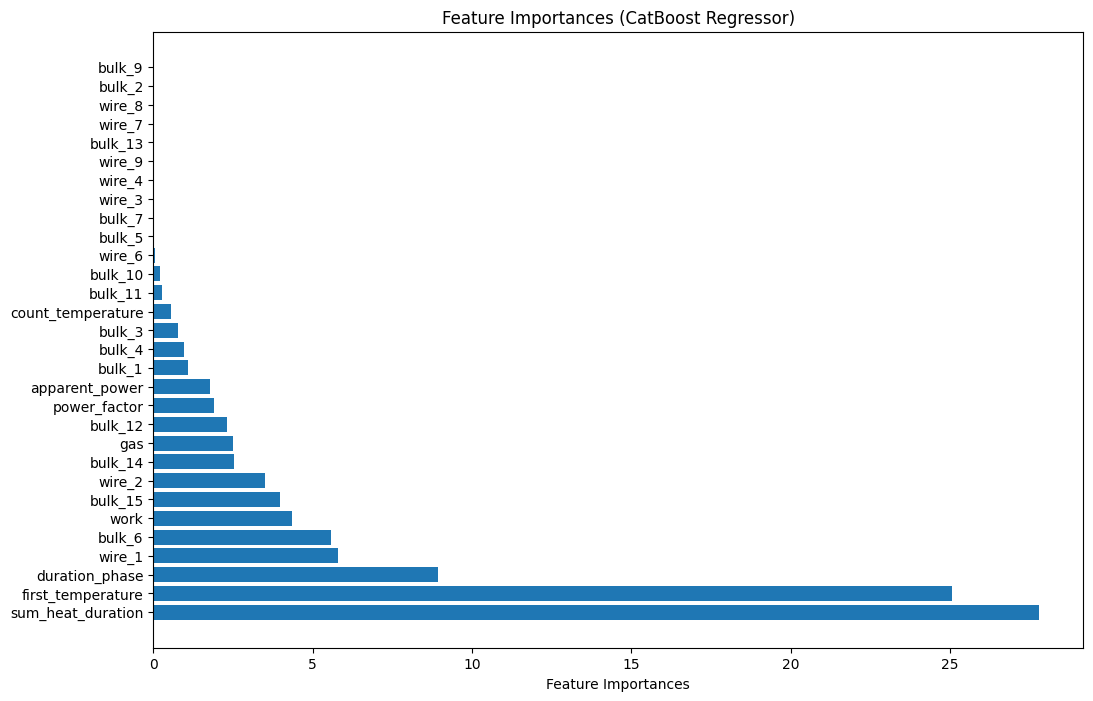

In [43]:
# Plot feature importances of CatBoost Regressor model
feature_importances = best_model_cb.feature_importances_
feature_names = x_train.columns

sorted_indices = feature_importances.argsort()[::-1]
sorted_feature_importances = feature_importances[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names, sorted_feature_importances)
plt.xlabel('Feature Importances')
plt.title('Feature Importances (CatBoost Regressor)')
plt.show()

In [44]:
# Calculate MAE of CatBoost Regressor model on test set
y_test_pred_cb = best_model_cb.predict(x_test)
test_mae_cb = mean_absolute_error(y_test, y_test_pred_cb)
print(f'MAE of CatBoost Regressor on test set: {test_mae_cb:.5}')

MAE of CatBoost Regressor on test set: 6.0034


Conclusion: <br>
The MAE of the best CatBoost Regressor model on the test set is 6. <br>
The MAE on the test set is comparable to the MAE on the training set, there is no model overfitting.

<h4>2.2.3. Select Best Model</h4> 

In [45]:
models_scores = {'Ridge Regression': [test_mae_lr, best_params_lr],
                'Catboost Regressor': [test_mae_cb, best_params_cb]
                }
models_scores = pd.DataFrame(models_scores, index=['Test MAE', 'Model Hyperparameters'])

display(models_scores)

,Ridge Regression,Catboost Regressor
Test MAE,6.467446,6.003401
Model Hyperparameters,"{'alpha': 0.5697035879539307, 'solver': 'lsqr'}","{'iterations': 313, 'learning_rate': 0.2395092..."


<h4>2.2.4. Modelling Conclusion</h4> 

Conclusion: <br>
The model with the lowest error on the test data is the CatBoost Regressor with model parameters: iterations 313, learning rate 0.239, regularization coefficient 0.67, model depth 4. <br>
The MAE of the best model is 6.00 on the test set. <br>
The Ridge Regression model has comparable results on the training and test sets and, additionally, trains faster and therefore can also be used for analysis.

<h2> Part 3. General Conclusion </h2> 

Based on historical data about production stages and alloy characteristics during steel production, models for predicting the final alloy temperature were developed. <br>
According to the analysis results, the CatBoost Regressor model was selected as the best model for prediction. The error of this model is minimal among all considered models, on average the temperature prediction of this model deviates from the actual value by 6.1 degrees.
According to the model results, the greatest influence on the final steel temperature is exerted by the initial alloy temperature and the total heating time of the alloy. Additionally, the time the alloy spends at this production stage and the power factor coefficient value also significantly affect the result. Among materials, the most significant are the volume of Wire 1 wire material addition and the volume of Bulk 6 bulk material addition.